# Initial and preparation

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import math
import numpy as np
from qiskit.quantum_info import Statevector
import qiskit

In [3]:
def qdata_to_circuit(qc, qdata):
    # for inst, qargs, cargs in qdata:
    #     qc.append(inst, qargs, cargs)
    for instr in qdata:
        qc.append(instr.operation, instr.qubits, instr.clbits)

# Function creation, based on Yu Shi's QMPI Library

In [4]:
import importlib
import MPI
import MPI_collective
importlib.reload(MPI_collective)
importlib.reload(MPI)

<module 'MPI' from 'c:\\Users\\DELL\\Desktop\\code\\tinthai_qmpi\\QMPI_Tinthai_Version\\Mixed_Topology\\MPI.py'>

In [5]:
def create_qnetwork(num_nodes, num_epr_qubits=2, num_epr_creg=1):
    sendqc_circuit = QuantumCircuit()

    nodes = []
    nodes_epr = []
    nodes_epr_creg = []

    for i in range(0, num_nodes):
        n = QuantumRegister(1, name=f"node{i}")
        nodes.append(n)
        n_epr = QuantumRegister(num_epr_qubits, name=f"node{i}_epr")
        nodes_epr.append(n_epr)
        n_creg = ClassicalRegister(num_epr_creg, name=f"node{i}_epr_creg")
        nodes_epr_creg.append(n_creg)
        sendqc_circuit.add_register(n)#, n_epr, n_creg)

    # epr_c = ClassicalRegister(2, name="epr_cr")
    # sendqc_circuit.add_register(epr_c)
    print(f"Created {len(nodes)} nodes to the circuit.")
    
    return sendqc_circuit, nodes, nodes_epr, nodes_epr_creg

In [6]:
def show_statevector(circuit):
    # 1 ลบการวัดออก (เพื่อดูสถานะก่อน collapse)
    circ_no_measure = circuit.remove_final_measurements(inplace=False)

    # 2 บอกให้ simulator เก็บ statevector
    circ_no_measure.save_statevector() 

    # 3 ใช้ simulator แบบ statevector
    sim_sv = AerSimulator(method='statevector')

    # 4 transpile และรัน
    ready_sv = transpile(circ_no_measure, sim_sv)
    result_sv = sim_sv.run(ready_sv).result()

    # 5 ดึงข้อมูล statevector ออกมา
    statevector = result_sv.data(0)['statevector']
    # print(statevector)

    # statevector จากผล simulation
    vec = Statevector(statevector)

    # แสดงเฉพาะค่าสำคัญ
    for i, amp in enumerate(vec.data):
        if not np.isclose(abs(amp), 0):  # ข้ามค่าที่แทบเป็นศูนย์
            print(f"|{i:0{vec.num_qubits}b}> : {amp}")

In [7]:
from qiskit import transpile
from qiskit_ibm_runtime.fake_provider import FakeAuckland, FakeBrisbane, FakeKawasaki, FakeTorino, FakePeekskill

def save_transpiled_circuits(circuit, approach, opt_level=3):
    """
    ฟังก์ชันสำหรับ Transpile วงจรและบันทึกเป็นไฟล์ภาพแยกตาม Backend
    """
    backends = {
        "Auckland": FakeAuckland(),
        "Brisbane": FakeBrisbane(),
        "Kawasaki": FakeKawasaki(),
        "Torino": FakeTorino(),
        "Peekskill": FakePeekskill()
    }
    
    print(f"เริ่มการ Transpile วงจรด้วย Optimization Level: {opt_level}")
    print("-" * 50)
    
    for name, backend_instance in backends.items():
        print(f"กำลังประมวลผล Backend: {name} ...")
        
        try:
            # 1. Transpile วงจร
            tp = transpile(circuit, backend=backend_instance, optimization_level=opt_level)
            
            # 2. กำหนดชื่อไฟล์ภาพ (บันทึกในโฟลเดอร์เดียวกันกับที่รันโค้ด)
            filename = f"{approach}_{name}.png"
            
            # 3. วาดกราฟและเซฟเป็นไฟล์
            tp.draw('mpl', fold=-1, filename=filename)
            
            print(f"  -> สำเร็จ! บันทึกไฟล์: {filename}")
            
        except Exception as e:
            print(f"  -> เกิดข้อผิดพลาดกับ {name}: {e}")
            
    print("-" * 50)
    print("ทำงานเสร็จสิ้น!")

In [8]:
def compute_depth_with_qiskit(circuit: qiskit.QuantumCircuit) -> float:
    """Compute the critical depth of the given quantum circuit.
    Critical depth = # of 2-qubit gates along the critical path / total # of 2-qubit gates.

    Args:
        circuit: A quantum circuit.

    Returns:
        The value of the depth feature for this circuit.
    """
    dag = qiskit.converters.circuit_to_dag(circuit)
    dag.remove_all_ops_named("barrier")
    longest_paths = dag.count_ops_longest_path()
    n_ed = sum(
        [
            longest_paths[name]
            for name in {op.name for op in dag.two_qubit_ops()}
            if name in longest_paths
        ]
    )
    n_e = len(dag.two_qubit_ops())

    if n_ed == 0:
        return 0

    return n_ed, n_e

# Star Topology

## 2-Switch

In [11]:
two_switch, two_switch_node, two_switch_epr, two_switch_creg = create_qnetwork(7, num_epr_qubits=2, num_epr_creg=1)
# Initiate ให้ node1[0] มีโอกาส ket(0) ~75%
two_switch.rx(math.pi/4, two_switch_node[0][0])   # หมุนแกน X มุม π/4 บน qubit 0
two_switch.ry(math.pi/4, two_switch_node[0][0])   # หมุนแกน X มุม π/4 บน qubit 0
two_switch.barrier(label='Data Ready')

Created 7 nodes to the circuit.


CircuitInstruction(operation=Instruction(name='barrier', num_qubits=7, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "node0"), index=0>, <Qubit register=(1, "node1"), index=0>, <Qubit register=(1, "node2"), index=0>, <Qubit register=(1, "node3"), index=0>, <Qubit register=(1, "node4"), index=0>, <Qubit register=(1, "node5"), index=0>, <Qubit register=(1, "node6"), index=0>), clbits=())

In [12]:
two_switch_class = MPI_collective.CollectiveMPI(two_switch)
two_switch_class.q = QuantumCircuit()
for qr in two_switch_node:
    two_switch_class.q.add_register(qr)
# for qr in two_switch_epr:
#     two_switch_class.q.add_register(qr)
for index, qr in enumerate(two_switch_epr):
    if index == 1:
        special_qr = QuantumRegister(7, 'node1_epr')
        two_switch_class.q.add_register(special_qr)
    else:
        two_switch_class.q.add_register(qr)
for qr in two_switch_creg:
    two_switch_class.q.add_register(qr)

two_switch_epr[1] = special_qr  # แทนที่ node1_epr ด้วย special_qr
# # Broadcast 
#operation = two_switch_class.brodcast([two_switch_node[0][0], two_switch_node[1][0], two_switch_node[2][0], two_switch_node[3][0], two_switch_node[4][0], two_switch_node[5][0], two_switch_node[6][0]])
# two_switch_class.q.draw('mpl', fold=-1)

In [13]:
# two_switch, two_switch_node, two_switch_epr, two_switch_creg
for i in range (1, 7):
    two_switch_class.q.h(two_switch_epr[i][0])
two_switch_class.q.cx(two_switch_epr[2][0], two_switch_epr[1][1])
two_switch_class.q.cx(two_switch_epr[3][0], two_switch_epr[1][2])
two_switch_class.q.cx(two_switch_epr[4][0], two_switch_epr[1][3])
two_switch_class.q.cx(two_switch_epr[5][0], two_switch_epr[1][4])
two_switch_class.q.cx(two_switch_epr[6][0], two_switch_epr[1][5])

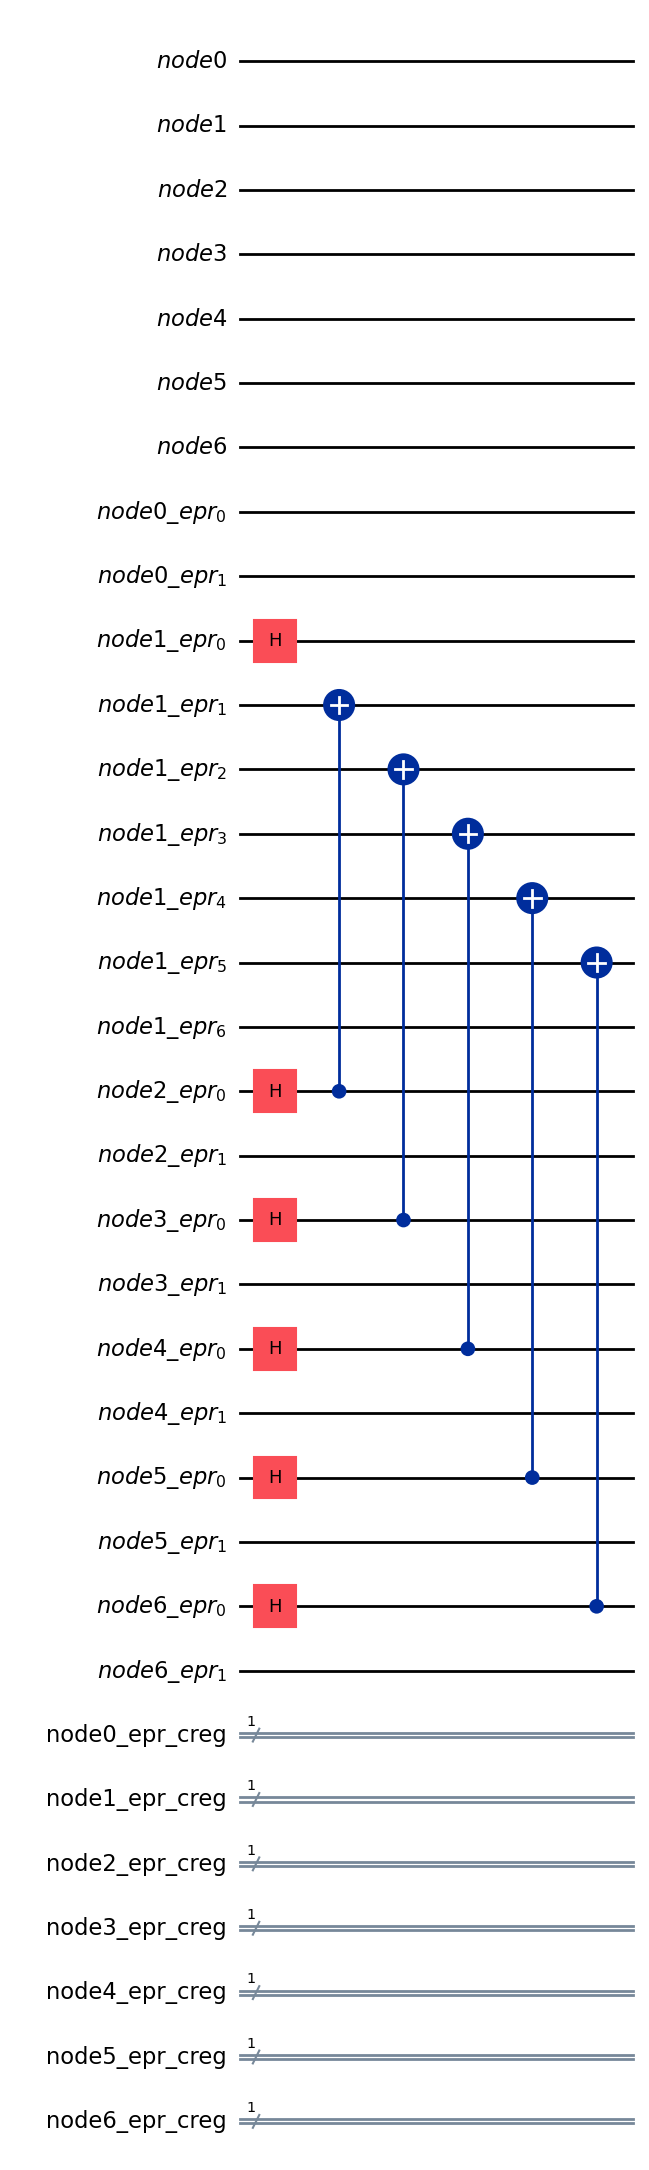

In [14]:
two_switch_class.q.draw('mpl', fold=-2)

In [ ]:
save_transpiled_circuits(two_switch_class.q, "two_switch", opt_level=3)

In [154]:
show_statevector(two_switch_class.q)

|000000000000000000000> : (0.853553390593274+0.14644660940672627j)
|000000000000001111111> : (0.3535533905932733-0.3535533905932739j)


## Factory node

### Original send to switch before creating GHZ

In [15]:
switch_factory_bf_ghz, switch_factory_bf_ghz_node, switch_factory_bf_ghz_epr, switch_factory_bf_ghz_creg = create_qnetwork(7, num_epr_qubits=2, num_epr_creg=1)
# Initiate ให้ node1[0] มีโอกาส ket(0) ~75%
switch_factory_bf_ghz.rx(math.pi/4, switch_factory_bf_ghz_node[0][0])   # หมุนแกน X มุม π/4 บน qubit 0
switch_factory_bf_ghz.ry(math.pi/4, switch_factory_bf_ghz_node[0][0])   # หมุนแกน X มุม π/4 บน qubit 0
switch_factory_bf_ghz.barrier(label='Data Ready')

Created 7 nodes to the circuit.


CircuitInstruction(operation=Instruction(name='barrier', num_qubits=7, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "node0"), index=0>, <Qubit register=(1, "node1"), index=0>, <Qubit register=(1, "node2"), index=0>, <Qubit register=(1, "node3"), index=0>, <Qubit register=(1, "node4"), index=0>, <Qubit register=(1, "node5"), index=0>, <Qubit register=(1, "node6"), index=0>), clbits=())

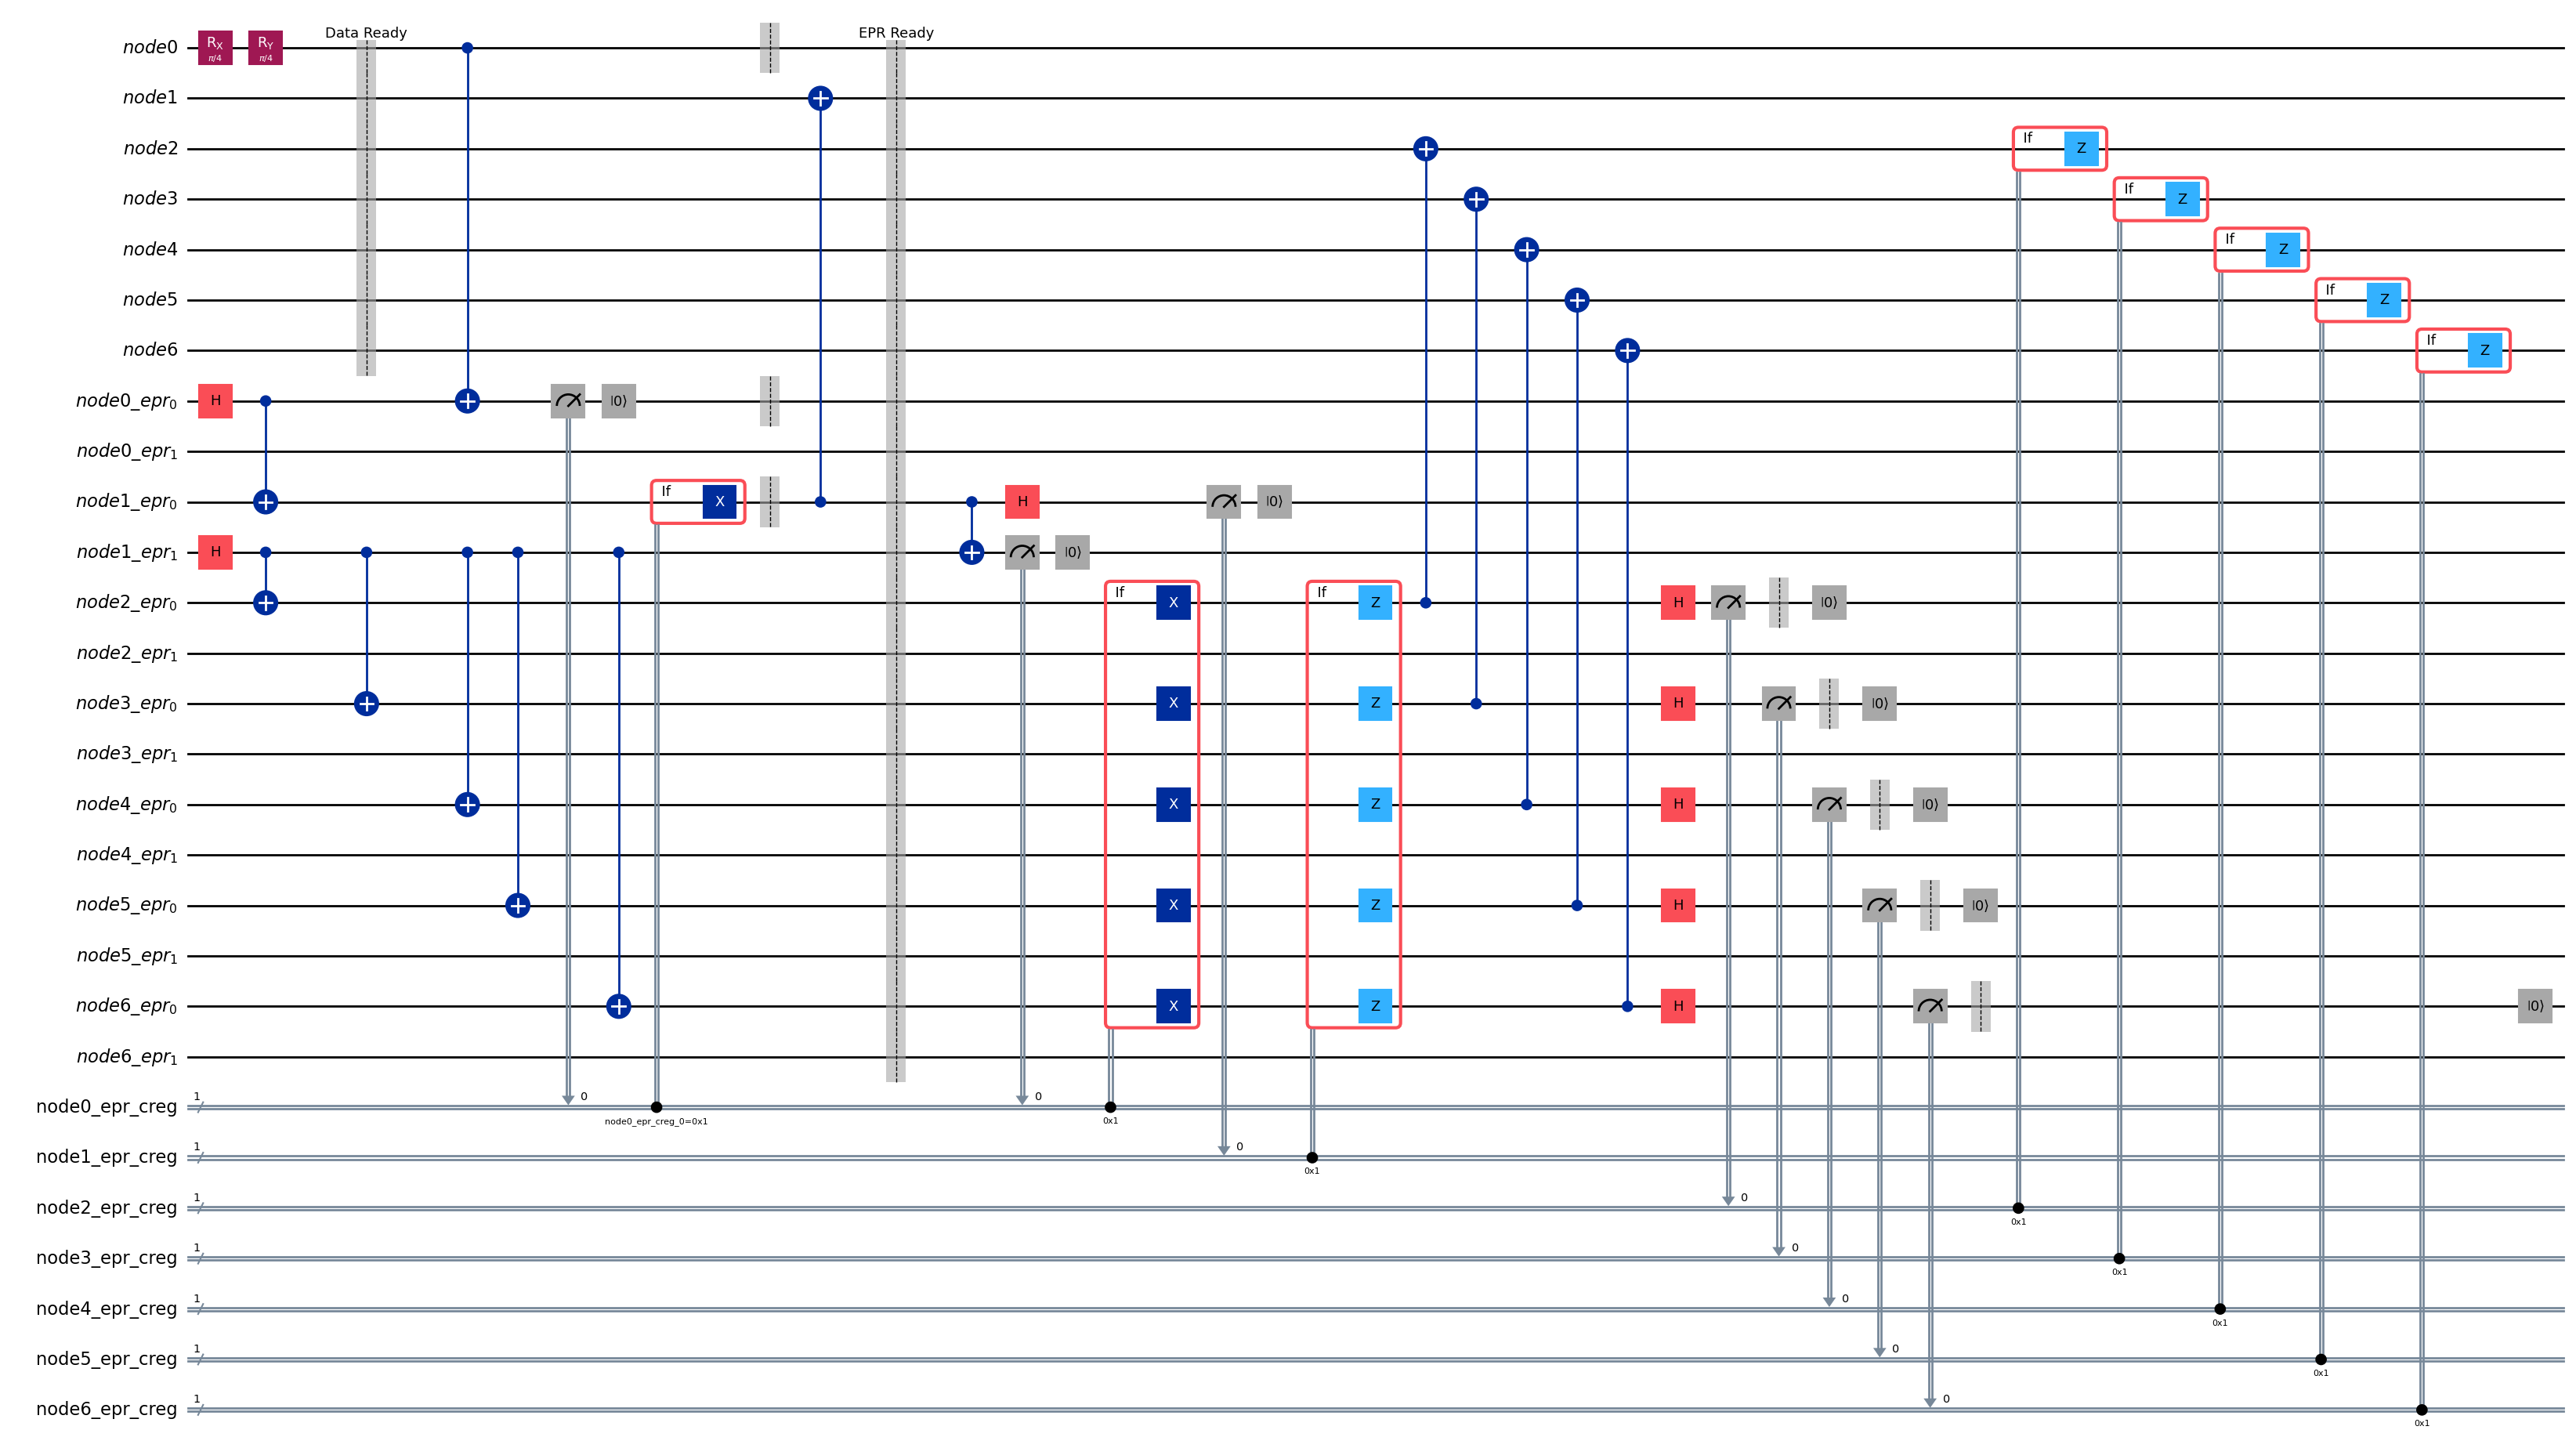

In [16]:
switch_factory_bf_ghz_class = MPI_collective.CollectiveMPI(switch_factory_bf_ghz)
switch_factory_bf_ghz_class = MPI.EPRsetup(switch_factory_bf_ghz_class.q, switch_factory_bf_ghz_node[0][0], switch_factory_bf_ghz_node[1][0])

switch_factory_bf_ghz_class.q.h(switch_factory_bf_ghz_epr[1][1])  # Root GHZ qubit
for i in range(2, 7):
    switch_factory_bf_ghz_class.q.cx(switch_factory_bf_ghz_epr[1][1], switch_factory_bf_ghz_epr[i][0])  # Root GHZ qubit -> Client GHZ qubits

# Copy from Node 0 to Node 1
operation = switch_factory_bf_ghz_class.copy()
qdata_to_circuit(switch_factory_bf_ghz_class.q, operation)
switch_factory_bf_ghz_class.q.cx(switch_factory_bf_ghz_epr[1][0], switch_factory_bf_ghz_node[1][0])

switch_factory_bf_ghz_class.q.barrier(label='EPR Ready')
# switch_factory_bf_ghz_class.q.cx(switch_factory_bf_ghz_epr[1][0], switch_factory_bf_ghz_epr[1][1])  # Root GHZ qubit -> Data qubit
# switch_factory_bf_ghz_class.q.h(switch_factory_bf_ghz_epr[1][0])  # Node 1 GHZ qubit

# switch_factory_bf_ghz_class.q.measure(switch_factory_bf_ghz_epr[1][1], switch_factory_bf_ghz_creg[0])  # Measure Root GHZ qubit
# switch_factory_bf_ghz_class.q.reset(switch_factory_bf_ghz_epr[1][1])
# with switch_factory_bf_ghz_class.q.if_test((switch_factory_bf_ghz_creg[0],1)):
#         switch_factory_bf_ghz_class.q.x(switch_factory_bf_ghz_epr[2][0])

# switch_factory_bf_ghz_class.q.measure(switch_factory_bf_ghz_epr[1][0], switch_factory_bf_ghz_creg[0])
# switch_factory_bf_ghz_class.q.barrier(switch_factory_bf_ghz_epr[2][0])
# with switch_factory_bf_ghz_class.q.if_test((switch_factory_bf_ghz_creg[0],1)):
#         switch_factory_bf_ghz_class.q.z(switch_factory_bf_ghz_epr[2][0])
# switch_factory_bf_ghz_class.q.reset(switch_factory_bf_ghz_epr[1][0])
# switch_factory_bf_ghz_class.q.cx(switch_factory_bf_ghz_epr[2][0], switch_factory_bf_ghz_node[2][0])

# with switch_factory_bf_ghz_class.q.if_test((switch_factory_bf_ghz_creg[0],1)):
#         switch_factory_bf_ghz_class.q.x(switch_factory_bf_ghz_epr[3][0])
# switch_factory_bf_ghz_class.q.cx(switch_factory_bf_ghz_epr[3][0], switch_factory_bf_ghz_node[3][0])
# with switch_factory_bf_ghz_class.q.if_test((switch_factory_bf_ghz_creg[0],1)):
#         switch_factory_bf_ghz_class.q.x(switch_factory_bf_ghz_epr[4][0])
# switch_factory_bf_ghz_class.q.cx(switch_factory_bf_ghz_epr[4][0], switch_factory_bf_ghz_node[4][0])
# with switch_factory_bf_ghz_class.q.if_test((switch_factory_bf_ghz_creg[0],1)):
#         switch_factory_bf_ghz_class.q.x(switch_factory_bf_ghz_epr[5][0])
# switch_factory_bf_ghz_class.q.cx(switch_factory_bf_ghz_epr[5][0], switch_factory_bf_ghz_node[5][0])
# with switch_factory_bf_ghz_class.q.if_test((switch_factory_bf_ghz_creg[0],1)):
#         switch_factory_bf_ghz_class.q.x(switch_factory_bf_ghz_epr[6][0])
# switch_factory_bf_ghz_class.q.cx(switch_factory_bf_ghz_epr[6][0], switch_factory_bf_ghz_node[6][0])

# #Cat-entangler
# # H gate
# switch_factory_bf_ghz_class.q.h(switch_factory_bf_ghz_epr[2][0])
# switch_factory_bf_ghz_class.q.h(switch_factory_bf_ghz_epr[3][0])
# switch_factory_bf_ghz_class.q.h(switch_factory_bf_ghz_epr[4][0])
# switch_factory_bf_ghz_class.q.h(switch_factory_bf_ghz_epr[5][0])
# switch_factory_bf_ghz_class.q.h(switch_factory_bf_ghz_epr[6][0]) # เพิ่มของตัวที่ 6

# # Measurement and Reset at EPR
# switch_factory_bf_ghz_class.q.measure(switch_factory_bf_ghz_epr[2][0], switch_factory_bf_ghz_creg[2])
# switch_factory_bf_ghz_class.q.barrier(switch_factory_bf_ghz_epr[2][0])
# switch_factory_bf_ghz_class.q.reset(switch_factory_bf_ghz_epr[2][0])

# switch_factory_bf_ghz_class.q.measure(switch_factory_bf_ghz_epr[3][0], switch_factory_bf_ghz_creg[3])
# switch_factory_bf_ghz_class.q.barrier(switch_factory_bf_ghz_epr[3][0])
# switch_factory_bf_ghz_class.q.reset(switch_factory_bf_ghz_epr[3][0])

# switch_factory_bf_ghz_class.q.measure(switch_factory_bf_ghz_epr[4][0], switch_factory_bf_ghz_creg[4])
# switch_factory_bf_ghz_class.q.barrier(switch_factory_bf_ghz_epr[4][0])
# switch_factory_bf_ghz_class.q.reset(switch_factory_bf_ghz_epr[4][0])

# switch_factory_bf_ghz_class.q.measure(switch_factory_bf_ghz_epr[5][0], switch_factory_bf_ghz_creg[5])
# switch_factory_bf_ghz_class.q.barrier(switch_factory_bf_ghz_epr[5][0])
# switch_factory_bf_ghz_class.q.reset(switch_factory_bf_ghz_epr[5][0])

# switch_factory_bf_ghz_class.q.measure(switch_factory_bf_ghz_epr[6][0], switch_factory_bf_ghz_creg[6])
# switch_factory_bf_ghz_class.q.barrier(switch_factory_bf_ghz_epr[6][0])
# switch_factory_bf_ghz_class.q.reset(switch_factory_bf_ghz_epr[6][0])

# # (Z-correction)
# with switch_factory_bf_ghz_class.q.if_test((switch_factory_bf_ghz_creg[2],1)):
#         switch_factory_bf_ghz_class.q.z(switch_factory_bf_ghz_node[2][0])

# with switch_factory_bf_ghz_class.q.if_test((switch_factory_bf_ghz_creg[3],1)):
#         switch_factory_bf_ghz_class.q.z(switch_factory_bf_ghz_node[3][0])

# with switch_factory_bf_ghz_class.q.if_test((switch_factory_bf_ghz_creg[4],1)):
#         switch_factory_bf_ghz_class.q.z(switch_factory_bf_ghz_node[4][0])

# with switch_factory_bf_ghz_class.q.if_test((switch_factory_bf_ghz_creg[5],1)):
#         switch_factory_bf_ghz_class.q.z(switch_factory_bf_ghz_node[5][0])

# with switch_factory_bf_ghz_class.q.if_test((switch_factory_bf_ghz_creg[6],1)):
#         switch_factory_bf_ghz_class.q.z(switch_factory_bf_ghz_node[6][0])     

# switch_factory_bf_ghz_class.q.draw('mpl', fold=-1)

switch_factory_bf_ghz_class.q.cx(switch_factory_bf_ghz_epr[1][0], switch_factory_bf_ghz_epr[1][1])  
switch_factory_bf_ghz_class.q.h(switch_factory_bf_ghz_epr[1][0])  

# วัด M1 (Root GHZ) แก้ด้วย X Correction (ต้องใส่ให้ครบทุกโหนด)
switch_factory_bf_ghz_class.q.measure(switch_factory_bf_ghz_epr[1][1], switch_factory_bf_ghz_creg[0])  
switch_factory_bf_ghz_class.q.reset(switch_factory_bf_ghz_epr[1][1])

with switch_factory_bf_ghz_class.q.if_test((switch_factory_bf_ghz_creg[0], 1)):
    switch_factory_bf_ghz_class.q.x(switch_factory_bf_ghz_epr[2][0])
    switch_factory_bf_ghz_class.q.x(switch_factory_bf_ghz_epr[3][0])
    switch_factory_bf_ghz_class.q.x(switch_factory_bf_ghz_epr[4][0])
    switch_factory_bf_ghz_class.q.x(switch_factory_bf_ghz_epr[5][0])
    switch_factory_bf_ghz_class.q.x(switch_factory_bf_ghz_epr[6][0])

# วัด M2 (Data Qubit) -> แก้ด้วย Z Correction (ใช้ creg[1] เพื่อความชัวร์ไม่ให้ทับกับบรรทัดบน)
switch_factory_bf_ghz_class.q.measure(switch_factory_bf_ghz_epr[1][0], switch_factory_bf_ghz_creg[1])
switch_factory_bf_ghz_class.q.reset(switch_factory_bf_ghz_epr[1][0])

with switch_factory_bf_ghz_class.q.if_test((switch_factory_bf_ghz_creg[1], 1)):
    switch_factory_bf_ghz_class.q.z(switch_factory_bf_ghz_epr[2][0])
    switch_factory_bf_ghz_class.q.z(switch_factory_bf_ghz_epr[3][0])
    switch_factory_bf_ghz_class.q.z(switch_factory_bf_ghz_epr[4][0])
    switch_factory_bf_ghz_class.q.z(switch_factory_bf_ghz_epr[5][0])
    switch_factory_bf_ghz_class.q.z(switch_factory_bf_ghz_epr[6][0])

switch_factory_bf_ghz_class.q.cx(switch_factory_bf_ghz_epr[2][0], switch_factory_bf_ghz_node[2][0])
switch_factory_bf_ghz_class.q.cx(switch_factory_bf_ghz_epr[3][0], switch_factory_bf_ghz_node[3][0])
switch_factory_bf_ghz_class.q.cx(switch_factory_bf_ghz_epr[4][0], switch_factory_bf_ghz_node[4][0])
switch_factory_bf_ghz_class.q.cx(switch_factory_bf_ghz_epr[5][0], switch_factory_bf_ghz_node[5][0])
switch_factory_bf_ghz_class.q.cx(switch_factory_bf_ghz_epr[6][0], switch_factory_bf_ghz_node[6][0])

# Cat entangler Uncompute
# เปลี่ยนแกนวัดด้วย H Gate
switch_factory_bf_ghz_class.q.h(switch_factory_bf_ghz_epr[2][0])
switch_factory_bf_ghz_class.q.h(switch_factory_bf_ghz_epr[3][0])
switch_factory_bf_ghz_class.q.h(switch_factory_bf_ghz_epr[4][0])
switch_factory_bf_ghz_class.q.h(switch_factory_bf_ghz_epr[5][0])
switch_factory_bf_ghz_class.q.h(switch_factory_bf_ghz_epr[6][0])

# วัดค่าและทำลาย EPR ทิ้ง (Decoupling)
switch_factory_bf_ghz_class.q.measure(switch_factory_bf_ghz_epr[2][0], switch_factory_bf_ghz_creg[2])
switch_factory_bf_ghz_class.q.barrier(switch_factory_bf_ghz_epr[2][0])
switch_factory_bf_ghz_class.q.reset(switch_factory_bf_ghz_epr[2][0])

switch_factory_bf_ghz_class.q.measure(switch_factory_bf_ghz_epr[3][0], switch_factory_bf_ghz_creg[3])
switch_factory_bf_ghz_class.q.barrier(switch_factory_bf_ghz_epr[3][0])
switch_factory_bf_ghz_class.q.reset(switch_factory_bf_ghz_epr[3][0])

switch_factory_bf_ghz_class.q.measure(switch_factory_bf_ghz_epr[4][0], switch_factory_bf_ghz_creg[4])
switch_factory_bf_ghz_class.q.barrier(switch_factory_bf_ghz_epr[4][0])
switch_factory_bf_ghz_class.q.reset(switch_factory_bf_ghz_epr[4][0])

switch_factory_bf_ghz_class.q.measure(switch_factory_bf_ghz_epr[5][0], switch_factory_bf_ghz_creg[5])
switch_factory_bf_ghz_class.q.barrier(switch_factory_bf_ghz_epr[5][0])
switch_factory_bf_ghz_class.q.reset(switch_factory_bf_ghz_epr[5][0])

switch_factory_bf_ghz_class.q.measure(switch_factory_bf_ghz_epr[6][0], switch_factory_bf_ghz_creg[6])
switch_factory_bf_ghz_class.q.barrier(switch_factory_bf_ghz_epr[6][0])
switch_factory_bf_ghz_class.q.reset(switch_factory_bf_ghz_epr[6][0])

# Phase Correction สำหรับ MBU (ทำที่ Data Qubit ปลายทาง)
with switch_factory_bf_ghz_class.q.if_test((switch_factory_bf_ghz_creg[2], 1)):
    switch_factory_bf_ghz_class.q.z(switch_factory_bf_ghz_node[2][0])
with switch_factory_bf_ghz_class.q.if_test((switch_factory_bf_ghz_creg[3], 1)):
    switch_factory_bf_ghz_class.q.z(switch_factory_bf_ghz_node[3][0])
with switch_factory_bf_ghz_class.q.if_test((switch_factory_bf_ghz_creg[4], 1)):
    switch_factory_bf_ghz_class.q.z(switch_factory_bf_ghz_node[4][0])
with switch_factory_bf_ghz_class.q.if_test((switch_factory_bf_ghz_creg[5], 1)):
    switch_factory_bf_ghz_class.q.z(switch_factory_bf_ghz_node[5][0])
with switch_factory_bf_ghz_class.q.if_test((switch_factory_bf_ghz_creg[6], 1)):
    switch_factory_bf_ghz_class.q.z(switch_factory_bf_ghz_node[6][0])

switch_factory_bf_ghz_class.q.draw('mpl', fold=-1)

In [17]:
save_transpiled_circuits(switch_factory_bf_ghz_class.q, "switch_factory_bf_ghz", opt_level=3)

เริ่มการ Transpile วงจรด้วย Optimization Level: 3
--------------------------------------------------
กำลังประมวลผล Backend: Auckland ...
  -> สำเร็จ! บันทึกไฟล์: switch_factory_bf_ghz_Auckland.png
กำลังประมวลผล Backend: Brisbane ...
  -> สำเร็จ! บันทึกไฟล์: switch_factory_bf_ghz_Brisbane.png
กำลังประมวลผล Backend: Kawasaki ...
  -> สำเร็จ! บันทึกไฟล์: switch_factory_bf_ghz_Kawasaki.png
กำลังประมวลผล Backend: Torino ...
  -> สำเร็จ! บันทึกไฟล์: switch_factory_bf_ghz_Torino.png
กำลังประมวลผล Backend: Peekskill ...
  -> สำเร็จ! บันทึกไฟล์: switch_factory_bf_ghz_Peekskill.png
--------------------------------------------------
ทำงานเสร็จสิ้น!


In [183]:
show_statevector(switch_factory_bf_ghz_class.q)

|000000000000000000000> : (0.8535533905932738+0.1464466094067263j)
|000000000000001111111> : (0.3535533905932733-0.3535533905932739j)


In [17]:
import pandas as pd
from qiskit import transpile

from qiskit_ibm_runtime.fake_provider import FakeAuckland, FakeBrisbane, FakeKawasaki, FakeTorino, FakePeekskill

# ฟังก์ชันมาตรฐานของ SupermarQ ถูกตั้งค่าให้รับ cirq.Circuit 
# สำหรับ Qiskit ต้องใช้ฟังก์ชัน _with_qiskit โดยเฉพาะ
try:
    from supermarq.converters import (
        compute_depth_with_qiskit,
        compute_entanglement_with_qiskit,
        compute_communication_with_qiskit
    )
except ImportError:
    from supermarq.features import (
        compute_depth_with_qiskit,
        compute_entanglement_with_qiskit,
        compute_communication_with_qiskit
    )

qc = switch_factory_bf_ghz_class.q

backends = {
    "fake_auckland": FakeAuckland(),
    "fake_brisbane": FakeBrisbane(),
    "fake_kawasaki": FakeKawasaki(),
    "fake_torino": FakeTorino(),
    "fake_peekskill": FakePeekskill()
}

results = []

print(f"🚀 เริ่มต้น Benchmark ด้วย SupermarQ สำหรับวงจรขนาด {qc.num_qubits} Qubits...")
print("-" * 50)

for name, backend in backends.items():
    print(f"⏳ กำลัง Transpile และคำนวณบน {name}...", end=" ")
    
    try:
        transpiled_qc = transpile(qc, backend=backend, optimization_level=3)
        
        # ใช้ฟังก์ชันสำหรับ Qiskit โดยเฉพาะ
        cd = compute_depth_with_qiskit(transpiled_qc)
        en = compute_entanglement_with_qiskit(transpiled_qc)
        pc = compute_communication_with_qiskit(transpiled_qc)
        
        results.append({
            "Backend": name,
            "CD (Depth)": round(cd, 4),
            "EN (Entanglement)": round(en, 4),
            "PC (Communication)": round(pc, 4)
        })
        print("✅ เสร็จสิ้น")
        
    except Exception as e:
        print(f"❌ ล้มเหลว ({str(e)})")
        results.append({
            "Backend": name,
            "CD (Depth)": "Error",
            "EN (Entanglement)": "Error",
            "PC (Communication)": "Error"
        })

df_results = pd.DataFrame(results)

print("\n📊 === SupermarQ Benchmark Results (Opt. Level 3) ===")

🚀 เริ่มต้น Benchmark ด้วย SupermarQ สำหรับวงจรขนาด 21 Qubits...
--------------------------------------------------
⏳ กำลัง Transpile และคำนวณบน fake_auckland... ✅ เสร็จสิ้น
⏳ กำลัง Transpile และคำนวณบน fake_brisbane... ✅ เสร็จสิ้น
⏳ กำลัง Transpile และคำนวณบน fake_kawasaki... ✅ เสร็จสิ้น
⏳ กำลัง Transpile และคำนวณบน fake_torino... ✅ เสร็จสิ้น
⏳ กำลัง Transpile และคำนวณบน fake_peekskill... ✅ เสร็จสิ้น

📊 === SupermarQ Benchmark Results (Opt. Level 3) ===


In [ ]:
# switch_factory_bf_ghz_class
df_results

,Backend,CD (Depth),EN (Entanglement),PC (Communication)
0,fake_auckland,0.6000,0.5085,0.0399
1,fake_brisbane,0.5263,0.1362,0.0019
2,fake_kawasaki,0.5263,0.1352,0.0021
3,fake_torino,0.6667,0.1844,0.0018
4,fake_peekskill,0.7273,0.1310,0.0399


### Original send to switch after creating GHZ

### Factory node with lower resource complexity (N+1)

# Tree based Topology

## Original binary tree

In [6]:
yu_shi_btree, yu_shi_btree_node, yu_shi_btree_epr, yu_shi_btree_creg = create_qnetwork(7, num_epr_qubits=2, num_epr_creg=2)
# Initiate ให้ node1[0] มีโอกาส ket(0) ~75%
yu_shi_btree.rx(math.pi/4, yu_shi_btree_node[0][0])   # หมุนแกน X มุม π/4 บน qubit 0
yu_shi_btree.ry(math.pi/4, yu_shi_btree_node[0][0])   # หมุนแกน X มุม π/4 บน qubit 0
yu_shi_btree.barrier(label='Data Ready')

Created 7 nodes to the circuit.


CircuitInstruction(operation=Instruction(name='barrier', num_qubits=7, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "node0"), index=0>, <Qubit register=(1, "node1"), index=0>, <Qubit register=(1, "node2"), index=0>, <Qubit register=(1, "node3"), index=0>, <Qubit register=(1, "node4"), index=0>, <Qubit register=(1, "node5"), index=0>, <Qubit register=(1, "node6"), index=0>), clbits=())

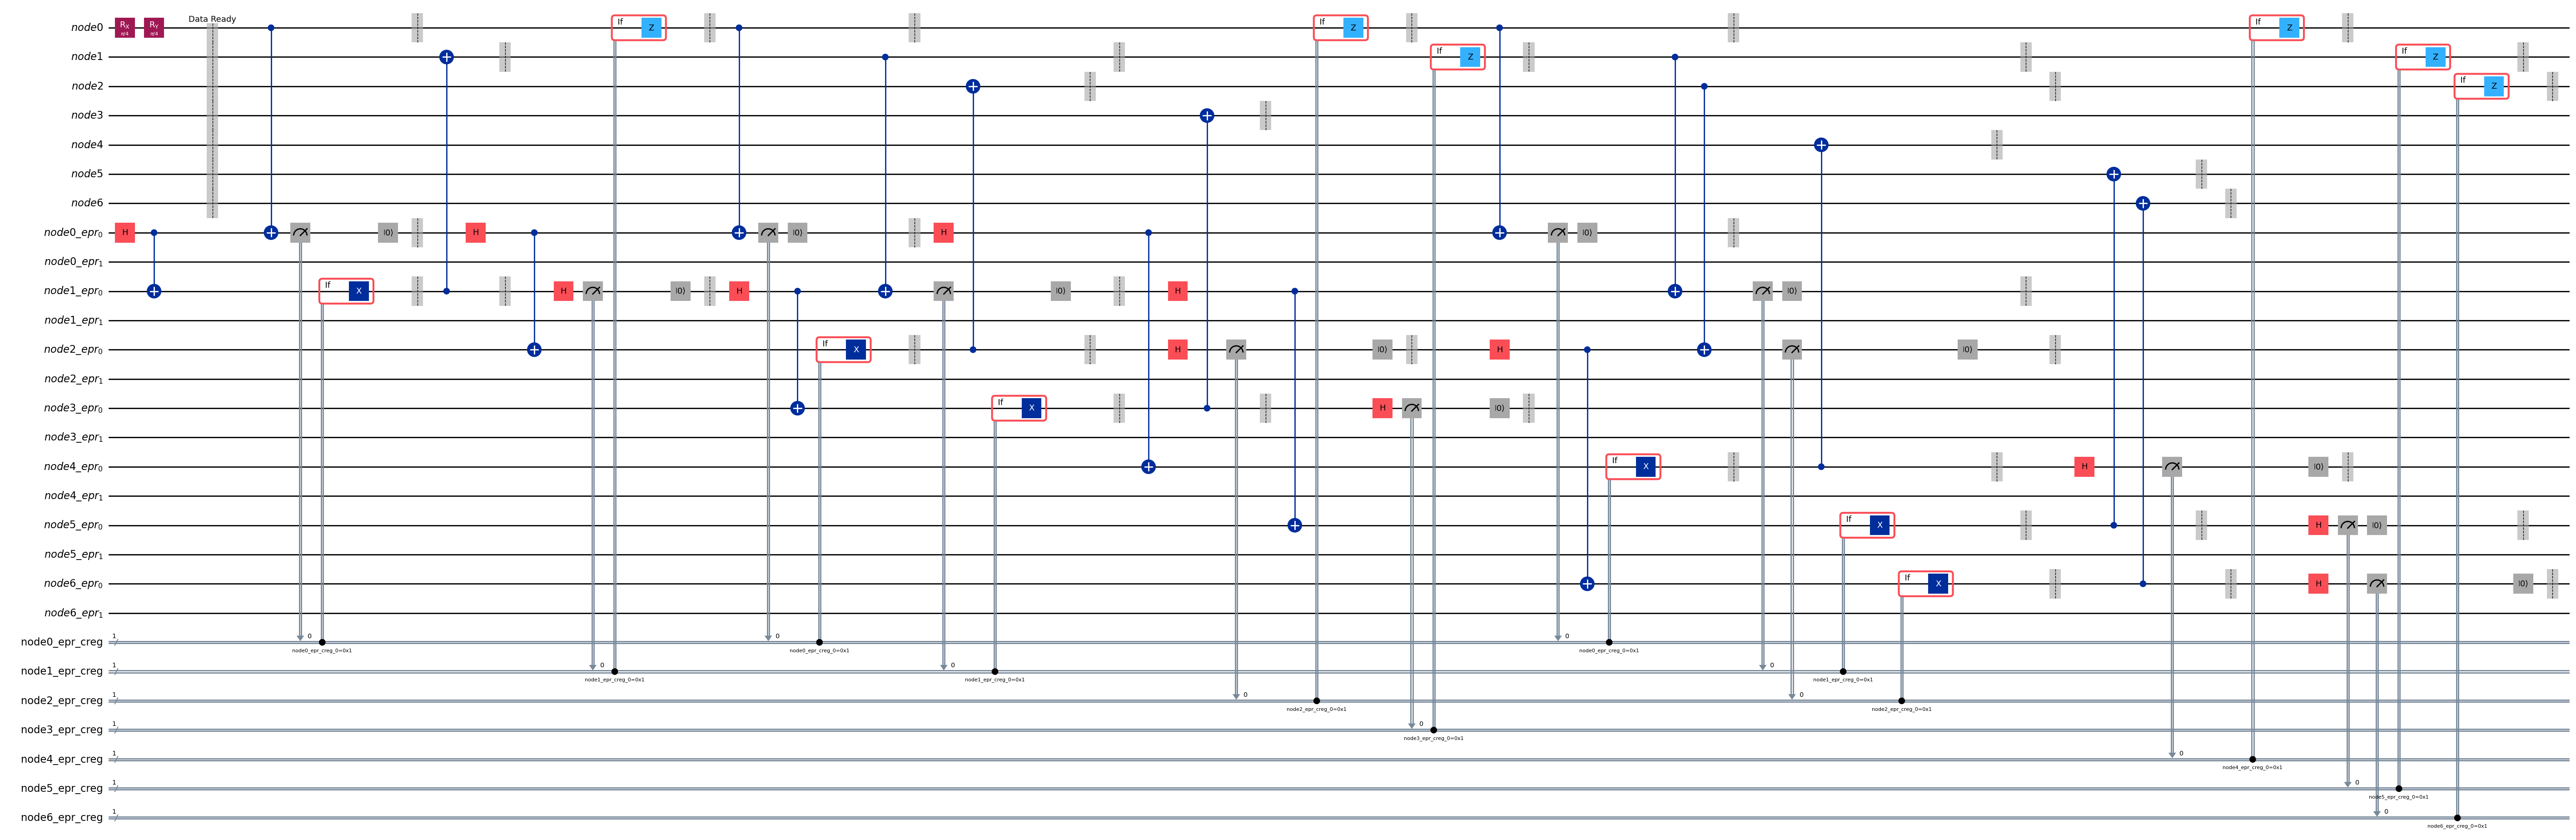

In [7]:
yu_shi_btree_class = MPI_collective.CollectiveMPI(yu_shi_btree)

# # Broadcast 
operation = yu_shi_btree_class.brodcast([yu_shi_btree_node[0][0], yu_shi_btree_node[1][0], yu_shi_btree_node[2][0], yu_shi_btree_node[3][0], yu_shi_btree_node[4][0], yu_shi_btree_node[5][0], yu_shi_btree_node[6][0]])
yu_shi_btree_class.q.draw('mpl', fold=-1)

In [8]:
from qiskit import transpile
from qiskit_ibm_runtime.fake_provider import FakeAuckland, FakeBrisbane, FakeKawasaki, FakeTorino, FakePeekskill

backend = {
    "Auckland": FakeAuckland(),
    "Brisbane": FakeBrisbane(),
    "Kawasaki": FakeKawasaki(),
    "Torino": FakeTorino(),
    "Peekskill": FakePeekskill()
}
	
for name, backend_instance in backend.items():
    tp = transpile(yu_shi_btree_class.q, backend=backend_instance, optimization_level=3)
    
    # บันทึกรูปภาพลงในโฟลเดอร์เดียวกันกับที่รันโค้ด
    filename = f"shiy_transpiled_{name}.png"
    tp.draw('mpl', fold=-1, filename=filename)
    
    print(f"-> บันทึกรูปภาพ {filename} สำเร็จ!\n")

print("ทำงานเสร็จสิ้นครบทุก Backend แล้ว!")
    

-> บันทึกรูปภาพ shiy_transpiled_Auckland.png สำเร็จ!

-> บันทึกรูปภาพ shiy_transpiled_Brisbane.png สำเร็จ!

-> บันทึกรูปภาพ shiy_transpiled_Kawasaki.png สำเร็จ!

-> บันทึกรูปภาพ shiy_transpiled_Torino.png สำเร็จ!

-> บันทึกรูปภาพ shiy_transpiled_Peekskill.png สำเร็จ!

ทำงานเสร็จสิ้นครบทุก Backend แล้ว!


In [113]:
show_statevector(yu_shi_btree_class.q)

|000000000000000000000> : (0.853553390593274+0.14644660940672635j)
|000000000000001111111> : (0.3535533905932735-0.353553390593274j)


In [21]:
import pandas as pd
from qiskit import transpile

from qiskit_ibm_runtime.fake_provider import FakeAuckland, FakeBrisbane, FakeKawasaki, FakeTorino, FakePeekskill

# ฟังก์ชันมาตรฐานของ SupermarQ ถูกตั้งค่าให้รับ cirq.Circuit 
# สำหรับ Qiskit ต้องใช้ฟังก์ชัน _with_qiskit โดยเฉพาะ
try:
    from supermarq.converters import (
        compute_depth_with_qiskit,
        compute_entanglement_with_qiskit,
        compute_communication_with_qiskit
    )
except ImportError:
    from supermarq.features import (
        compute_depth_with_qiskit,
        compute_entanglement_with_qiskit,
        compute_communication_with_qiskit
    )

qc = yu_shi_btree_class.q

backends = {
    "fake_auckland": FakeAuckland(),
    "fake_brisbane": FakeBrisbane(),
    "fake_kawasaki": FakeKawasaki(),
    "fake_torino": FakeTorino(),
    "fake_peekskill": FakePeekskill()
}

results = []

print(f"🚀 เริ่มต้น Benchmark ด้วย SupermarQ สำหรับวงจรขนาด {qc.num_qubits} Qubits...")
print("-" * 50)

for name, backend in backends.items():
    print(f"⏳ กำลัง Transpile และคำนวณบน {name}...", end=" ")
    
    try:
        transpiled_qc = transpile(qc, backend=backend, optimization_level=3)
        
        # ใช้ฟังก์ชันสำหรับ Qiskit โดยเฉพาะ
        cd = compute_depth_with_qiskit(transpiled_qc)
        en = compute_entanglement_with_qiskit(transpiled_qc)
        pc = compute_communication_with_qiskit(transpiled_qc)
        
        results.append({
            "Backend": name,
            "CD (Depth)": round(cd, 4),
            "EN (Entanglement)": round(en, 4),
            "PC (Communication)": round(pc, 4)
        })
        print("✅ เสร็จสิ้น")
        
    except Exception as e:
        print(f"❌ ล้มเหลว ({str(e)})")
        results.append({
            "Backend": name,
            "CD (Depth)": "Error",
            "EN (Entanglement)": "Error",
            "PC (Communication)": "Error"
        })

df_results = pd.DataFrame(results)

print("\n📊 === SupermarQ Benchmark Results (Opt. Level 3) ===")

🚀 เริ่มต้น Benchmark ด้วย SupermarQ สำหรับวงจรขนาด 21 Qubits...
--------------------------------------------------
⏳ กำลัง Transpile และคำนวณบน fake_auckland... ✅ เสร็จสิ้น
⏳ กำลัง Transpile และคำนวณบน fake_brisbane... ✅ เสร็จสิ้น
⏳ กำลัง Transpile และคำนวณบน fake_kawasaki... ✅ เสร็จสิ้น
⏳ กำลัง Transpile และคำนวณบน fake_torino... ✅ เสร็จสิ้น
⏳ กำลัง Transpile และคำนวณบน fake_peekskill... ✅ เสร็จสิ้น

📊 === SupermarQ Benchmark Results (Opt. Level 3) ===


In [ ]:
#yu_shi_btree_class
df_results

,Backend,CD (Depth),EN (Entanglement),PC (Communication)
0,fake_auckland,0.5152,0.3511,0.0370
1,fake_brisbane,0.5897,0.1349,0.0017
2,fake_kawasaki,0.6923,0.1359,0.0016
3,fake_torino,0.5897,0.1884,0.0019
4,fake_peekskill,0.6111,0.1286,0.0370


## Binary tree with optimized

## Binary fat tree

# Linear / Chain Topology

Created 7 nodes to the circuit.


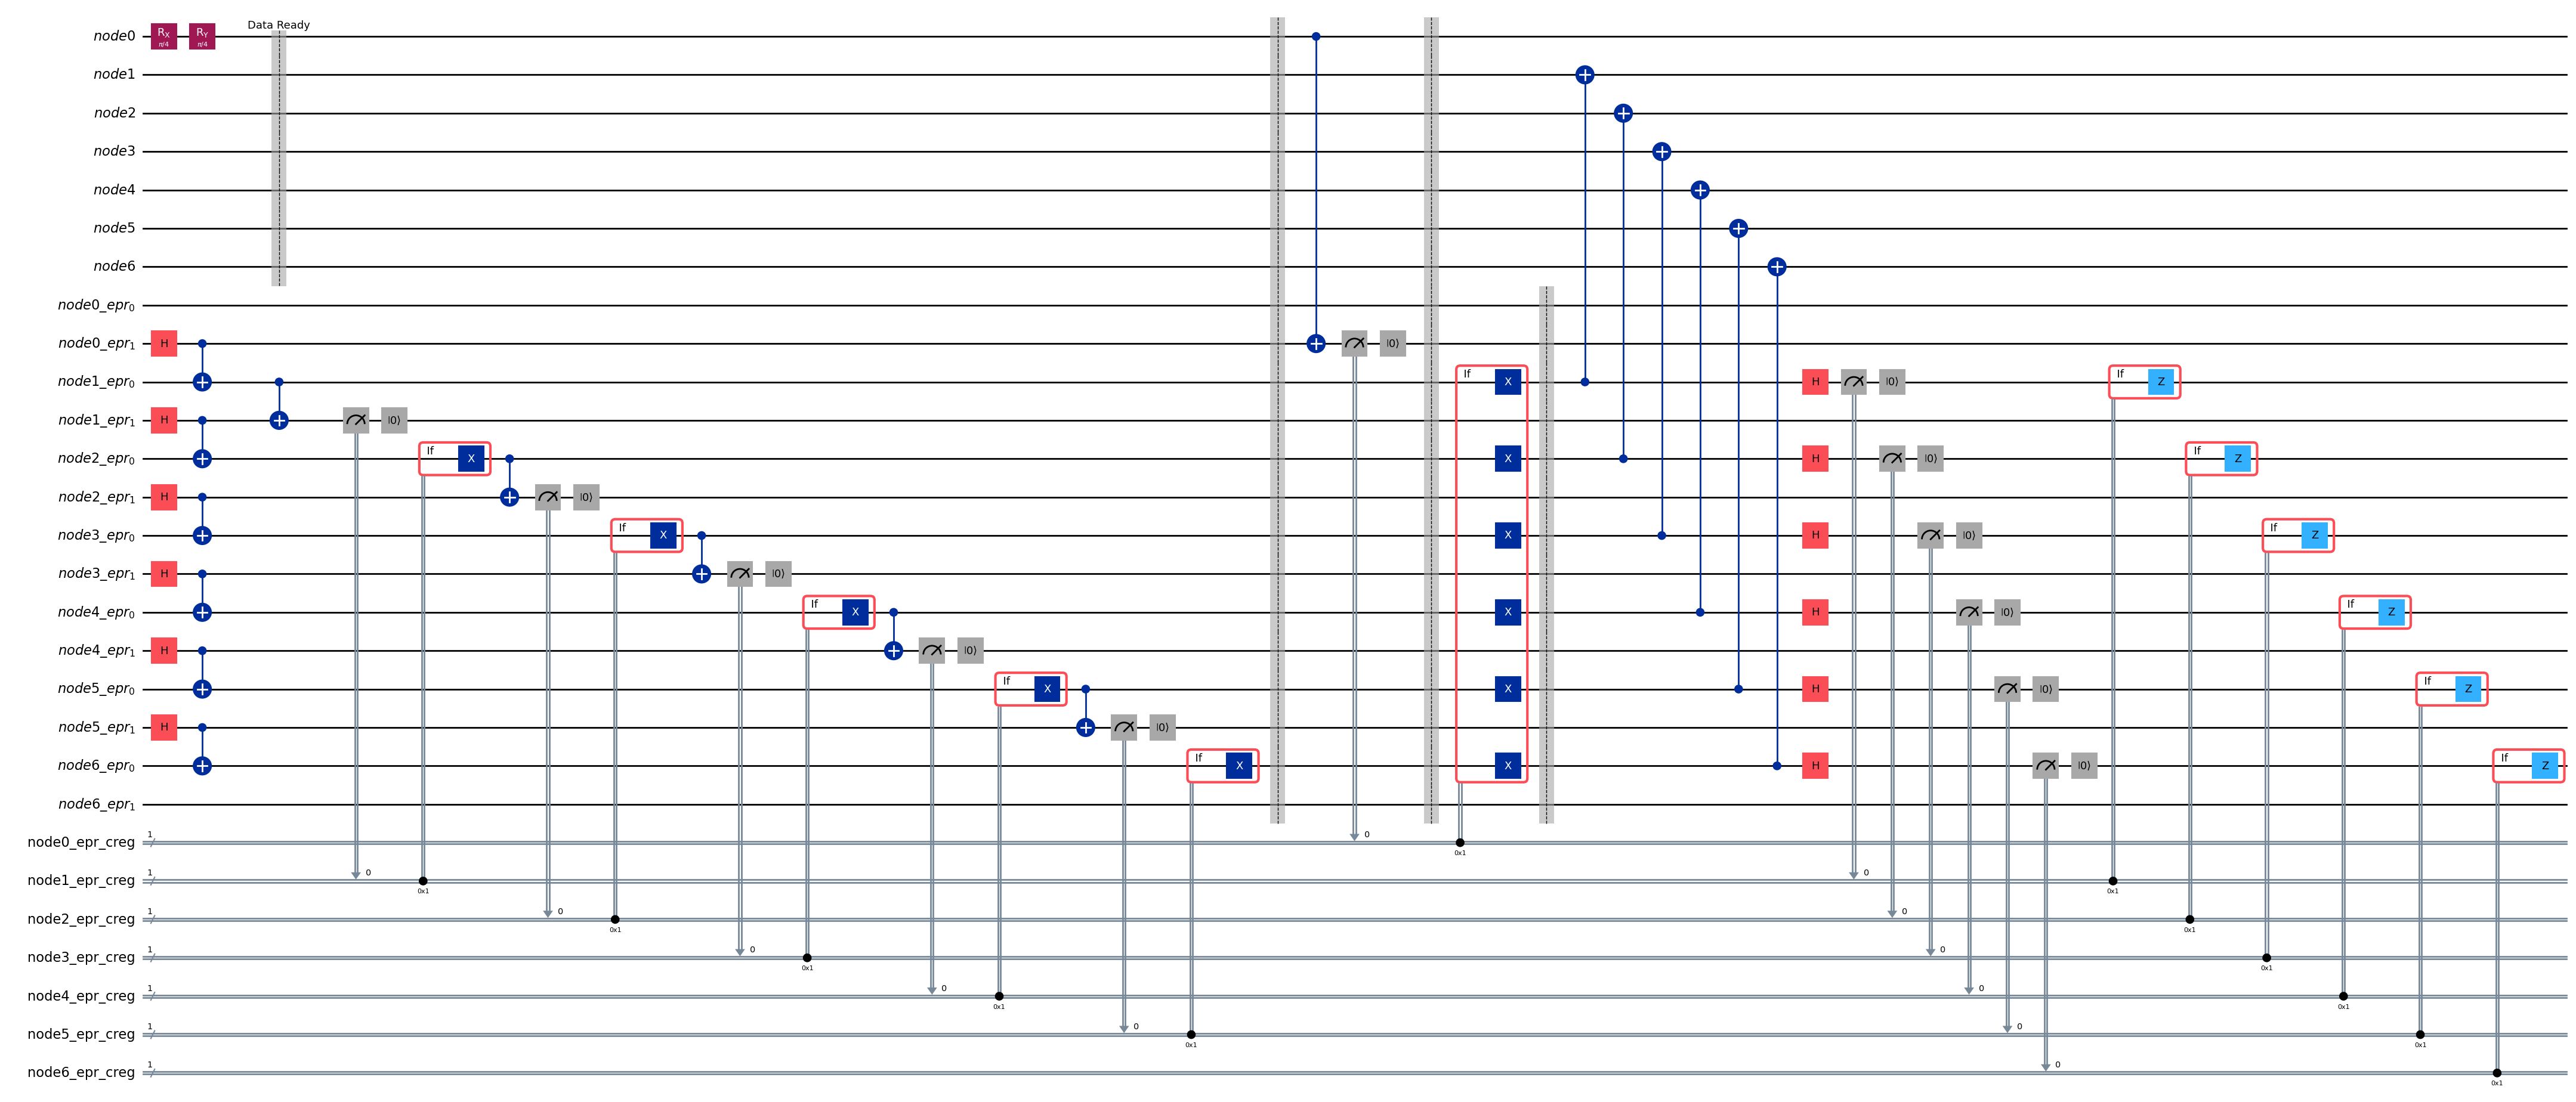

In [25]:
linear_chain, linear_chain_node, linear_chain_epr, linear_chain_creg = create_qnetwork(7, num_epr_qubits=2, num_epr_creg=1)
# Initiate ให้ node1[0] มีโอกาส ket(0) ~75%
linear_chain.rx(math.pi/4, linear_chain_node[0][0])   # หมุนแกน X มุม π/4 บน qubit 0
linear_chain.ry(math.pi/4, linear_chain_node[0][0])   # หมุนแกน X มุม π/4 บน qubit 0
linear_chain.barrier(label='Data Ready')
linear_chain_class = MPI_collective.CollectiveMPI(linear_chain)
linear_chain_class = MPI.EPRsetup(linear_chain_class.q, linear_chain_node[0][0], linear_chain_node[1][0])

# linear_chain_class.q.
for i in range(6):
    linear_chain_class.q.h(linear_chain_epr[i][1])
    linear_chain_class.q.cx(linear_chain_epr[i][1], linear_chain_epr[i+1][0])


# for i in range(1, 6):
#     linear_chain_class.q.cx(linear_chain_epr[i][0], linear_chain_epr[i][1])
# for i in range(1, 6):
#     linear_chain_class.q.measure(linear_chain_epr[i][1], linear_chain_creg[i])
#     linear_chain_class.q.reset(linear_chain_epr[i][1])
#     with linear_chain_class.q.if_test((linear_chain_creg[i], 1)):
#         linear_chain_class.q.x(linear_chain_epr[i+1][0])

# Corrected Loop
for i in range(1, 6):
    # 1. Entangle
    linear_chain_class.q.cx(linear_chain_epr[i][0], linear_chain_epr[i][1])
    # 2. Measure
    linear_chain_class.q.measure(linear_chain_epr[i][1], linear_chain_creg[i])
    # 3. Reset
    linear_chain_class.q.reset(linear_chain_epr[i][1])
    # 4. Correct BEFORE moving to the next pair
    with linear_chain_class.q.if_test((linear_chain_creg[i], 1)):
        linear_chain_class.q.x(linear_chain_epr[i+1][0])


# ##Barrier
# for i in range(0, 7):
linear_chain_class.q.barrier()
####
## GHZ Ready, send data to epr 1
linear_chain_class.q.cx(linear_chain_node[0][0], linear_chain_epr[0][1])
linear_chain_class.q.measure(linear_chain_epr[0][1], linear_chain_creg[0])
linear_chain_class.q.reset(linear_chain_epr[0][1])
linear_chain_class.q.barrier()
# for i in range(1, 6):
#     with linear_chain_class.q.if_test((linear_chain_creg[i-1], 1)):
#         linear_chain_class.q.x(linear_chain_epr[i][0])
with linear_chain_class.q.if_test((linear_chain_creg[0], 1)):
    for i in range(1, 7):
        linear_chain_class.q.x(linear_chain_epr[i][0])

##Barrier
for i in range(0, 7):
    linear_chain_class.q.barrier(linear_chain_epr[i])
####

for i in range(1, 7):
    linear_chain_class.q.cx(linear_chain_epr[i][0], linear_chain_node[i][0])

for i in range(1, 7):
    linear_chain_class.q.h(linear_chain_epr[i][0])
    linear_chain_class.q.measure(linear_chain_epr[i][0], linear_chain_creg[i])
    linear_chain_class.q.reset(linear_chain_epr[i][0])

for i in range(1, 7):
    with linear_chain_class.q.if_test((linear_chain_creg[i], 1)):
        linear_chain_class.q.z(linear_chain_epr[i][0])

linear_chain_class.q.draw('mpl',  fold = -1)

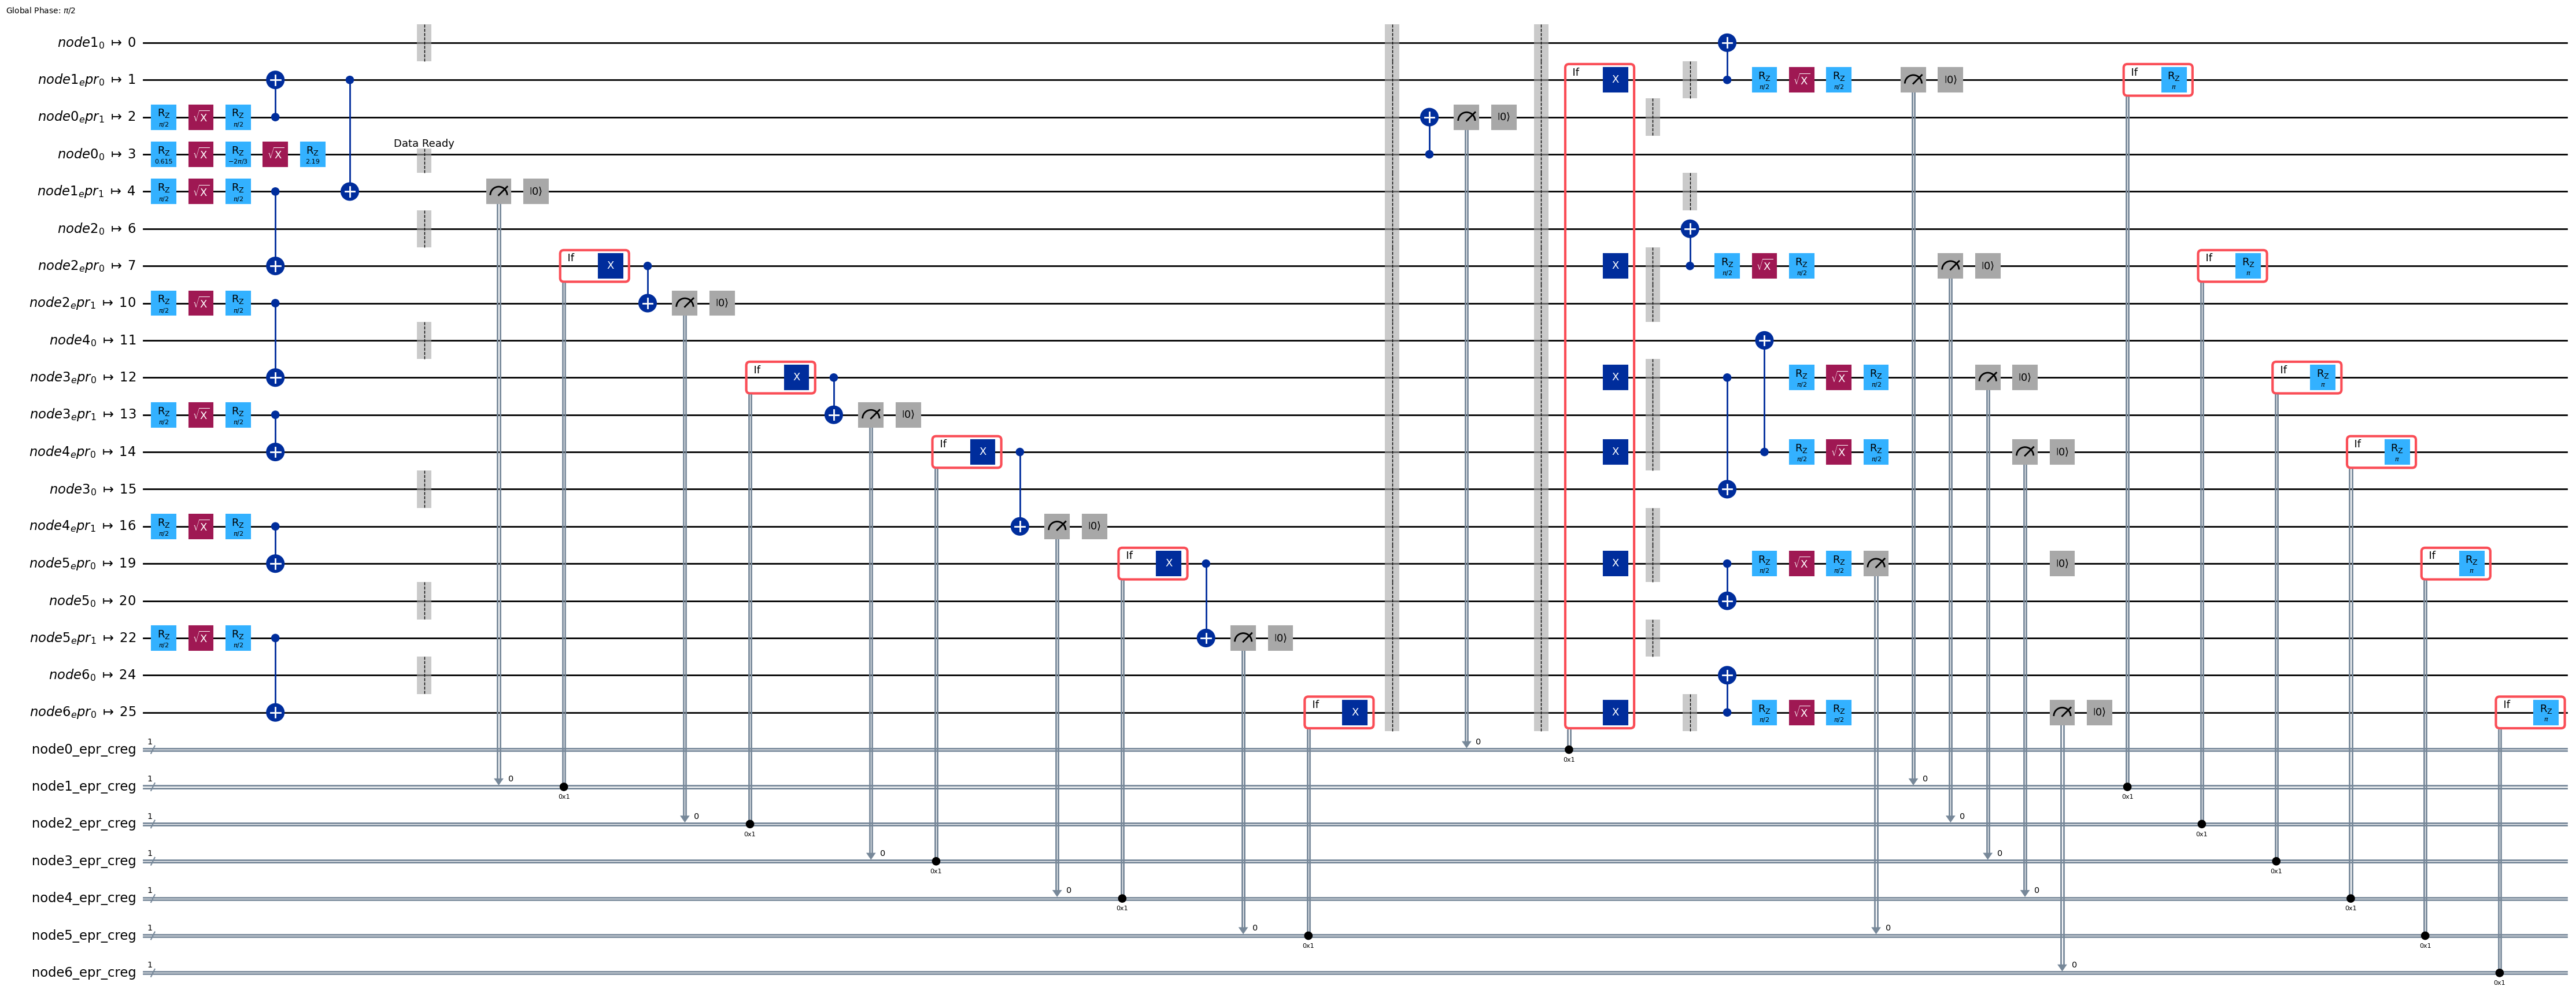

In [26]:
from qiskit import transpile
from qiskit_ibm_runtime.fake_provider import FakeAuckland, FakeBrisbane, FakeKawasaki, FakeTorino, FakePeekskill
tp = transpile(linear_chain_class.q, backend=FakeAuckland(), optimization_level=3)
tp.draw('mpl', fold=-1)

In [31]:
import qiskit
from typing import Tuple

# ตั้งชื่อใหม่เพื่อไม่ให้ซ้ำกับของเดิม เช่น เติม _custom ต่อท้าย
def custom_compute_depth_with_qiskit(circuit: qiskit.QuantumCircuit) -> Tuple[int, int, float]:
    dag = qiskit.converters.circuit_to_dag(circuit)
    dag.remove_all_ops_named("barrier")
    longest_paths = dag.count_ops_longest_path()
    
    n_ed = sum(
        [
            longest_paths[name]
            for name in {op.name for op in dag.two_qubit_ops()}
            if name in longest_paths
        ]
    )
    n_e = len(dag.two_qubit_ops())

    # คำนวณผลลัพธ์
    if n_ed == 0:
        result = 0.0
    else:
        result = n_ed / n_e

    # ส่งค่ากลับออกมาเป็น Tuple (n_ed, n_e, ผลลัพธ์)
    return n_ed, n_e, result, longest_paths, [op.name for op in dag.two_qubit_ops()]

print(custom_compute_depth_with_qiskit(linear_chain_class.q))

(7, 18, 0.3888888888888889, {'cx': 7, 'h': 2, 'reset': 1, 'measure': 6, 'if_else': 7}, ['cx', 'cx', 'cx', 'cx', 'cx', 'cx', 'cx', 'cx', 'cx', 'cx', 'cx', 'cx', 'cx', 'cx', 'cx', 'cx', 'cx', 'cx'])


In [10]:
print(compute_depth_with_qiskit(linear_chain_class.q))

(7, 18)


In [22]:
save_transpiled_circuits(linear_chain_class.q, "linear_chain", opt_level=3)

เริ่มการ Transpile วงจรด้วย Optimization Level: 3
--------------------------------------------------
กำลังประมวลผล Backend: Auckland ...
  -> สำเร็จ! บันทึกไฟล์: linear_chain_Auckland.png
กำลังประมวลผล Backend: Brisbane ...
  -> สำเร็จ! บันทึกไฟล์: linear_chain_Brisbane.png
กำลังประมวลผล Backend: Kawasaki ...
  -> สำเร็จ! บันทึกไฟล์: linear_chain_Kawasaki.png
กำลังประมวลผล Backend: Torino ...
  -> สำเร็จ! บันทึกไฟล์: linear_chain_Torino.png
กำลังประมวลผล Backend: Peekskill ...
  -> สำเร็จ! บันทึกไฟล์: linear_chain_Peekskill.png
--------------------------------------------------
ทำงานเสร็จสิ้น!


In [ ]:
show_statevector(linear_chain_class.q)

|000000000000000000000> : (0.853553390593274+0.14644660940672632j)
|000000000000001111111> : (0.3535533905932734-0.353553390593274j)


In [24]:
import pandas as pd
from qiskit import transpile

from qiskit_ibm_runtime.fake_provider import FakeAuckland, FakeBrisbane, FakeKawasaki, FakeTorino, FakePeekskill

# ฟังก์ชันมาตรฐานของ SupermarQ ถูกตั้งค่าให้รับ cirq.Circuit 
# สำหรับ Qiskit ต้องใช้ฟังก์ชัน _with_qiskit โดยเฉพาะ
try:
    from supermarq.converters import (
        compute_depth_with_qiskit,
        compute_entanglement_with_qiskit,
        compute_communication_with_qiskit
    )
except ImportError:
    from supermarq.features import (
        compute_depth_with_qiskit,
        compute_entanglement_with_qiskit,
        compute_communication_with_qiskit
    )

qc = linear_chain_class.q

backends = {
    "fake_auckland": FakeAuckland(),
    "fake_brisbane": FakeBrisbane(),
    "fake_kawasaki": FakeKawasaki(),
    "fake_torino": FakeTorino(),
    "fake_peekskill": FakePeekskill()
}

results = []

print(f"🚀 เริ่มต้น Benchmark ด้วย SupermarQ สำหรับวงจรขนาด {qc.num_qubits} Qubits...")
print("-" * 50)

for name, backend in backends.items():
    print(f"⏳ กำลัง Transpile และคำนวณบน {name}...", end=" ")
    
    try:
        transpiled_qc = transpile(qc, backend=backend, optimization_level=3)
        
        # ใช้ฟังก์ชันสำหรับ Qiskit โดยเฉพาะ
        cd = compute_depth_with_qiskit(transpiled_qc)
        en = compute_entanglement_with_qiskit(transpiled_qc)
        pc = compute_communication_with_qiskit(transpiled_qc)
        
        results.append({
            "Backend": name,
            "CD (Depth)": round(cd, 4),
            "EN (Entanglement)": round(en, 4),
            "PC (Communication)": round(pc, 4)
        })
        print("✅ เสร็จสิ้น")
        
    except Exception as e:
        print(f"❌ ล้มเหลว ({str(e)})")
        results.append({
            "Backend": name,
            "CD (Depth)": "Error",
            "EN (Entanglement)": "Error",
            "PC (Communication)": "Error"
        })

df_results = pd.DataFrame(results)

print("\n📊 === SupermarQ Benchmark Results (Opt. Level 3) ===")

🚀 เริ่มต้น Benchmark ด้วย SupermarQ สำหรับวงจรขนาด 21 Qubits...
--------------------------------------------------
⏳ กำลัง Transpile และคำนวณบน fake_auckland... ✅ เสร็จสิ้น
⏳ กำลัง Transpile และคำนวณบน fake_brisbane... ✅ เสร็จสิ้น
⏳ กำลัง Transpile และคำนวณบน fake_kawasaki... ✅ เสร็จสิ้น
⏳ กำลัง Transpile และคำนวณบน fake_torino... ✅ เสร็จสิ้น
⏳ กำลัง Transpile และคำนวณบน fake_peekskill... ✅ เสร็จสิ้น

📊 === SupermarQ Benchmark Results (Opt. Level 3) ===


In [ ]:
#linear_chain_class
df_results

,Backend,CD (Depth),EN (Entanglement),PC (Communication)
0,fake_auckland,0.3889,0.3051,0.0513
1,fake_brisbane,0.3889,0.1118,0.0022
2,fake_kawasaki,0.3889,0.1259,0.0022
3,fake_torino,0.3889,0.1250,0.0021
4,fake_peekskill,0.3889,0.1111,0.0513


## Better Linear

Created 7 nodes to the circuit.


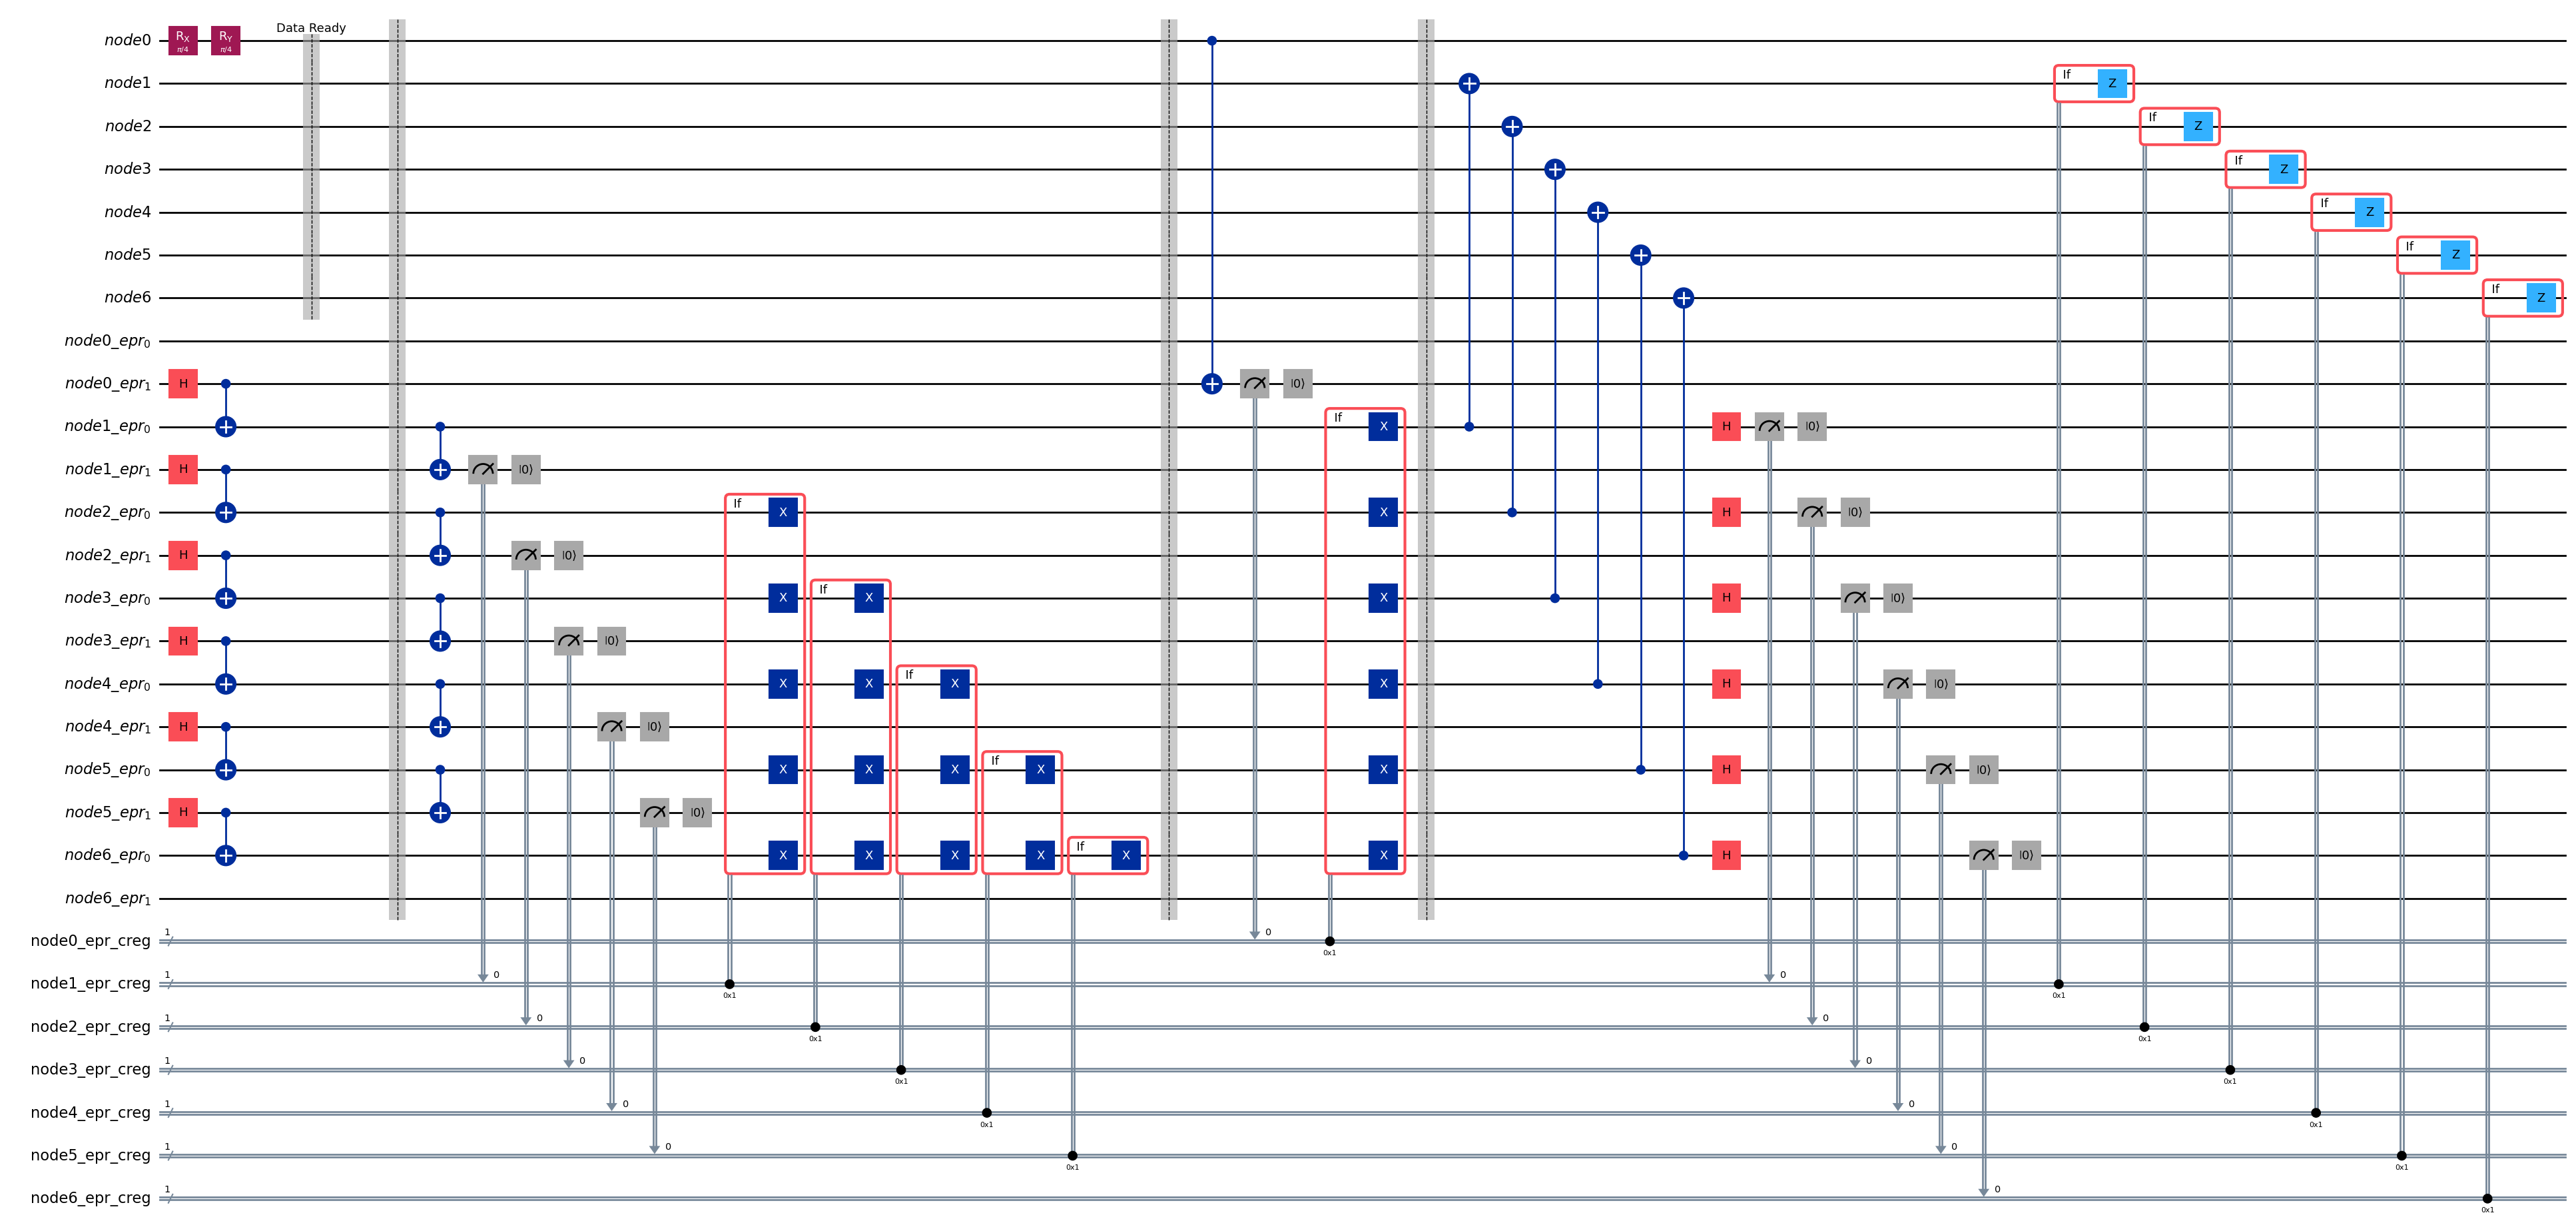

In [34]:
linear_chain, linear_chain_node, linear_chain_epr, linear_chain_creg = create_qnetwork(7, num_epr_qubits=2, num_epr_creg=1)
# Initiate ให้ node1[0] มีโอกาส ket(0) ~75%
linear_chain.rx(math.pi/4, linear_chain_node[0][0])   # หมุนแกน X มุม π/4 บน qubit 0
linear_chain.ry(math.pi/4, linear_chain_node[0][0])   # หมุนแกน X มุม π/4 บน qubit 0
linear_chain.barrier(label='Data Ready')
linear_chain_class = MPI_collective.CollectiveMPI(linear_chain)
linear_chain_class = MPI.EPRsetup(linear_chain_class.q, linear_chain_node[0][0], linear_chain_node[1][0])
# ---------------------------------------------------------
# Step 1-3 เหมือนเดิม (สร้าง EPR และ Parallel BSM)
# ---------------------------------------------------------
for i in range(6):
    linear_chain_class.q.h(linear_chain_epr[i][1])
    linear_chain_class.q.cx(linear_chain_epr[i][1], linear_chain_epr[i+1][0])

linear_chain_class.q.barrier() 

for i in range(1, 6):
    linear_chain_class.q.cx(linear_chain_epr[i][0], linear_chain_epr[i][1])

for i in range(1, 6):
    linear_chain_class.q.measure(linear_chain_epr[i][1], linear_chain_creg[i])
    linear_chain_class.q.reset(linear_chain_epr[i][1])

for i in range(1, 6):
    with linear_chain_class.q.if_test((linear_chain_creg[i], 1)):
        # ถ้า Node i พัง ต้องแก้ทุก Node ที่อยู่หลังจากมัน (i+1 ไปจนถึง 6)
        for k in range(i + 1, 7):
            linear_chain_class.q.x(linear_chain_epr[k][0])

linear_chain_class.q.barrier()


linear_chain_class.q.cx(linear_chain_node[0][0], linear_chain_epr[0][1])
linear_chain_class.q.measure(linear_chain_epr[0][1], linear_chain_creg[0])
linear_chain_class.q.reset(linear_chain_epr[0][1])

with linear_chain_class.q.if_test((linear_chain_creg[0], 1)):
    for i in range(1, 7):
        linear_chain_class.q.x(linear_chain_epr[i][0])

linear_chain_class.q.barrier()

# ---------------------------------------------------------
for i in range(1, 7):
    linear_chain_class.q.cx(linear_chain_epr[i][0], linear_chain_node[i][0])

for i in range(1, 7):
    linear_chain_class.q.h(linear_chain_epr[i][0])
    linear_chain_class.q.measure(linear_chain_epr[i][0], linear_chain_creg[i])
    linear_chain_class.q.reset(linear_chain_epr[i][0])

for i in range(1, 7):
    with linear_chain_class.q.if_test((linear_chain_creg[i], 1)):
        linear_chain_class.q.z(linear_chain_node[i][0]) 

linear_chain_class.q.draw('mpl', fold=-1)

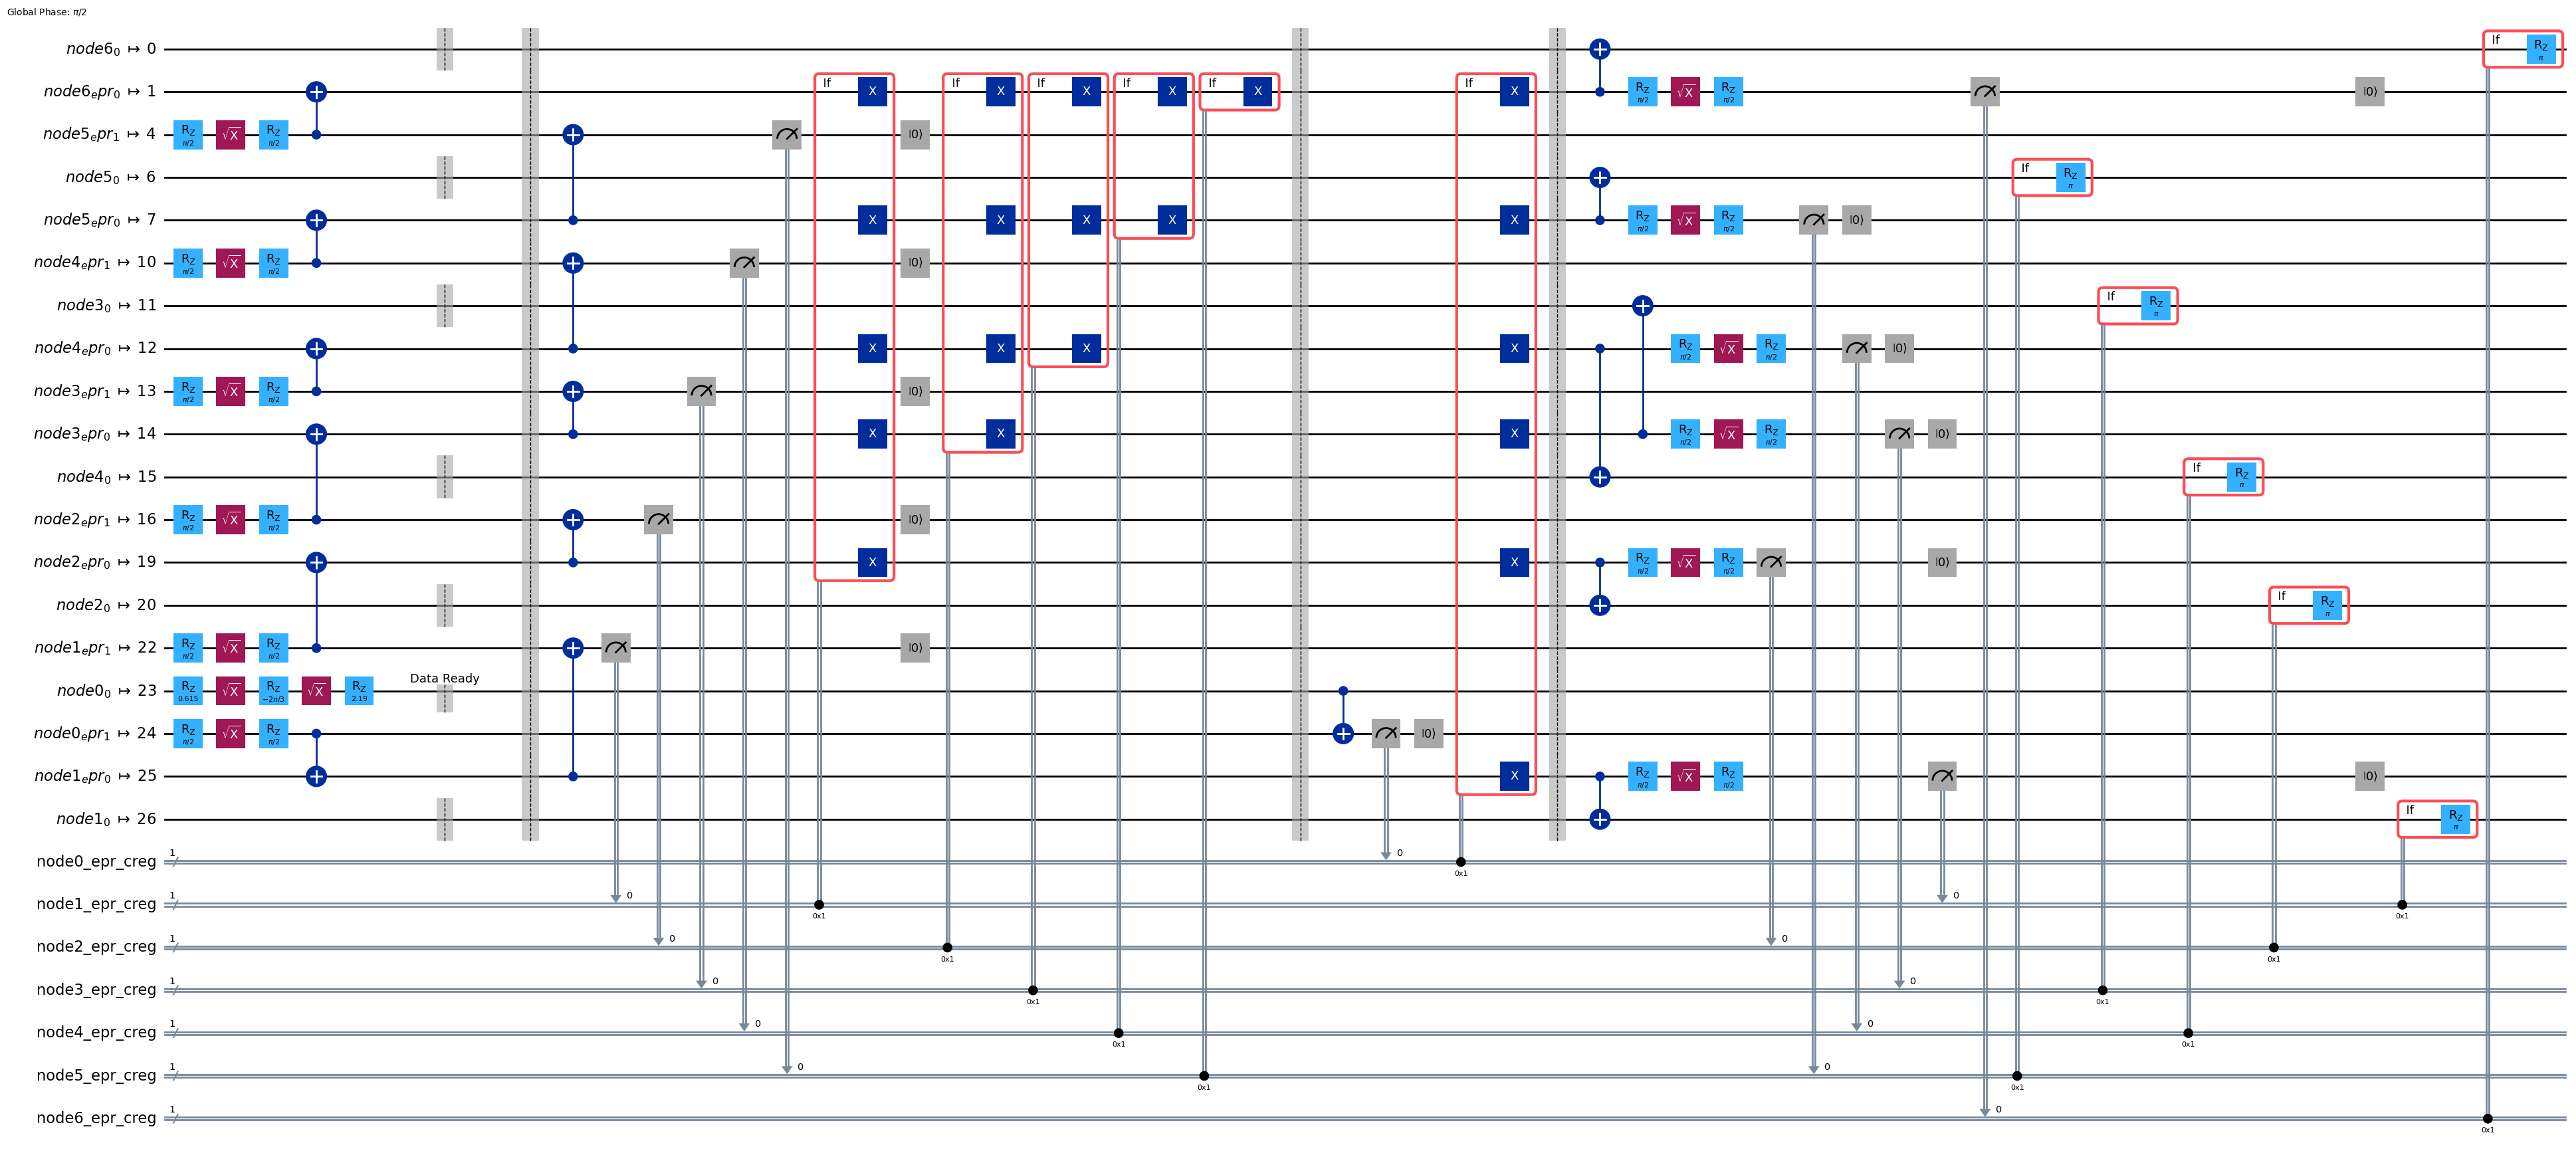

In [35]:
from qiskit import transpile
from qiskit_ibm_runtime.fake_provider import FakeAuckland, FakeBrisbane, FakeKawasaki, FakeTorino, FakePeekskill
tp = transpile(linear_chain_class.q, backend=FakeAuckland(), optimization_level=3)
tp.draw('mpl', fold=-1)

In [33]:
import qiskit
from typing import Tuple

# ตั้งชื่อใหม่เพื่อไม่ให้ซ้ำกับของเดิม เช่น เติม _custom ต่อท้าย
def custom_compute_depth_with_qiskit(circuit: qiskit.QuantumCircuit) -> Tuple[int, int, float]:
    dag = qiskit.converters.circuit_to_dag(circuit)
    dag.remove_all_ops_named("barrier")
    longest_paths = dag.count_ops_longest_path()
    
    n_ed = sum(
        [
            longest_paths[name]
            for name in {op.name for op in dag.two_qubit_ops()}
            if name in longest_paths
        ]
    )
    n_e = len(dag.two_qubit_ops())

    # คำนวณผลลัพธ์
    if n_ed == 0:
        result = 0.0
    else:
        result = n_ed / n_e

    # ส่งค่ากลับออกมาเป็น Tuple (n_ed, n_e, ผลลัพธ์)
    return n_ed, n_e, result, longest_paths, [op.name for op in dag.two_qubit_ops()]

print(custom_compute_depth_with_qiskit(linear_chain_class.q))

(10, 19, 0.5263157894736842, {'cx': 3, 'measure': 2, 'h': 2, 'if_else': 7}, ['cx', 'cx', 'cx', 'cx', 'cx', 'cx', 'cx', 'cx', 'cx', 'cx', 'cx', 'if_else', 'cx', 'cx', 'cx', 'cx', 'cx', 'cx', 'cx'])


In [18]:
print(compute_depth_with_qiskit(linear_chain_class.q))

(10, 19)


In [24]:
save_transpiled_circuits(linear_chain_class.q, "linear_chain_op", opt_level=3)

เริ่มการ Transpile วงจรด้วย Optimization Level: 3
--------------------------------------------------
กำลังประมวลผล Backend: Auckland ...
  -> สำเร็จ! บันทึกไฟล์: linear_chain_op_Auckland.png
กำลังประมวลผล Backend: Brisbane ...
  -> สำเร็จ! บันทึกไฟล์: linear_chain_op_Brisbane.png
กำลังประมวลผล Backend: Kawasaki ...
  -> สำเร็จ! บันทึกไฟล์: linear_chain_op_Kawasaki.png
กำลังประมวลผล Backend: Torino ...
  -> สำเร็จ! บันทึกไฟล์: linear_chain_op_Torino.png
กำลังประมวลผล Backend: Peekskill ...
  -> สำเร็จ! บันทึกไฟล์: linear_chain_op_Peekskill.png
--------------------------------------------------
ทำงานเสร็จสิ้น!


In [ ]:
show_statevector(linear_chain_class.q)

|000000000000000000000> : (0.8535533905932737+0.14644660940672624j)
|000000000000001111111> : (0.35355339059327356-0.35355339059327445j)


In [27]:
import pandas as pd
from qiskit import transpile

from qiskit_ibm_runtime.fake_provider import FakeAuckland, FakeBrisbane, FakeKawasaki, FakeTorino, FakePeekskill

# ฟังก์ชันมาตรฐานของ SupermarQ ถูกตั้งค่าให้รับ cirq.Circuit 
# สำหรับ Qiskit ต้องใช้ฟังก์ชัน _with_qiskit โดยเฉพาะ
try:
    from supermarq.converters import (
        compute_depth_with_qiskit,
        compute_entanglement_with_qiskit,
        compute_communication_with_qiskit
    )
except ImportError:
    from supermarq.features import (
        compute_depth_with_qiskit,
        compute_entanglement_with_qiskit,
        compute_communication_with_qiskit
    )

qc = linear_chain_class.q

backends = {
    "fake_auckland": FakeAuckland(),
    "fake_brisbane": FakeBrisbane(),
    "fake_kawasaki": FakeKawasaki(),
    "fake_torino": FakeTorino(),
    "fake_peekskill": FakePeekskill()
}

results = []

print(f"🚀 เริ่มต้น Benchmark ด้วย SupermarQ สำหรับวงจรขนาด {qc.num_qubits} Qubits...")
print("-" * 50)

for name, backend in backends.items():
    print(f"⏳ กำลัง Transpile และคำนวณบน {name}...", end=" ")
    
    try:
        transpiled_qc = transpile(qc, backend=backend, optimization_level=3)
        
        # ใช้ฟังก์ชันสำหรับ Qiskit โดยเฉพาะ
        cd = compute_depth_with_qiskit(transpiled_qc)
        en = compute_entanglement_with_qiskit(transpiled_qc)
        pc = compute_communication_with_qiskit(transpiled_qc)
        
        results.append({
            "Backend": name,
            "CD (Depth)": round(cd, 4),
            "EN (Entanglement)": round(en, 4),
            "PC (Communication)": round(pc, 4)
        })
        print("✅ เสร็จสิ้น")
        
    except Exception as e:
        print(f"❌ ล้มเหลว ({str(e)})")
        results.append({
            "Backend": name,
            "CD (Depth)": "Error",
            "EN (Entanglement)": "Error",
            "PC (Communication)": "Error"
        })

df_results = pd.DataFrame(results)

print("\n📊 === SupermarQ Benchmark Results (Opt. Level 3) ===")

🚀 เริ่มต้น Benchmark ด้วย SupermarQ สำหรับวงจรขนาด 21 Qubits...
--------------------------------------------------
⏳ กำลัง Transpile และคำนวณบน fake_auckland... ✅ เสร็จสิ้น
⏳ กำลัง Transpile และคำนวณบน fake_brisbane... ✅ เสร็จสิ้น
⏳ กำลัง Transpile และคำนวณบน fake_kawasaki... ✅ เสร็จสิ้น
⏳ กำลัง Transpile และคำนวณบน fake_torino... ✅ เสร็จสิ้น
⏳ กำลัง Transpile และคำนวณบน fake_peekskill... ✅ เสร็จสิ้น

📊 === SupermarQ Benchmark Results (Opt. Level 3) ===


In [ ]:
#linear_chain_class_better
df_results

,Backend,CD (Depth),EN (Entanglement),PC (Communication)
0,fake_auckland,0.4737,0.3220,0.0541
1,fake_brisbane,0.5263,0.1080,0.0024
2,fake_kawasaki,0.5263,0.0892,0.0024
3,fake_torino,0.4737,0.1275,0.0022
4,fake_peekskill,0.5263,0.0913,0.0541


# Mesh / Grid Topology

# Hyper cube Topology

# Testing

In [155]:
test,test_node,test_epr,test_creg = create_qnetwork(7)

Created 7 nodes to the circuit.


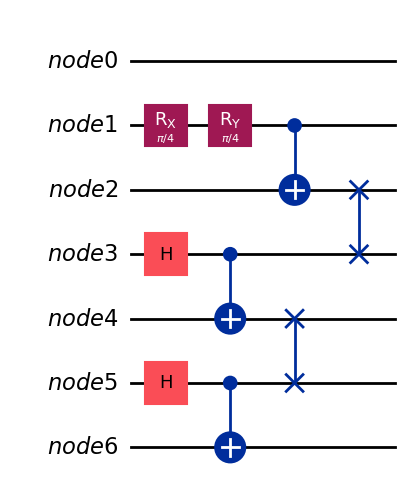

In [156]:
import math
test.rx(math.pi/4, test_node[1])
test.ry(math.pi/4, test_node[1])
# test.h(test_node[1])
test.cx(test_node[1], test_node[2])
test.h(test_node[3])
test.cx(test_node[3], test_node[4])
test.h(test_node[5])
test.cx(test_node[5], test_node[6])
# test.swap(test_node[0], test_node[1])
test.swap(test_node[2], test_node[3])
test.swap(test_node[4], test_node[5])
test.draw('mpl', fold=-1)

In [157]:
import numpy as np
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

def show_partial_state(circuit, indices_to_keep=None):
    """
    แสดงผลสถานะควอนตัมเฉพาะ Qubits ที่สนใจ
    :param circuit: QuantumCircuit ที่ต้องการรัน
    :param indices_to_keep: List ของ index ที่ต้องการเก็บไว้ (เช่น [0, 1]) 
                            ถ้าเป็น None จะแสดงทั้งหมด
    """
    # 1. คัดลอกวงจรและลบการวัดออกเพื่อดู State ก่อน collapse
    circ_no_measure = circuit.remove_final_measurements(inplace=False)
    
    # 2. เตรียม Simulator และเก็บ Statevector
    circ_no_measure.save_statevector()
    sim_sv = AerSimulator(method='statevector')
    
    # 3. Transpile และ Run
    ready_sv = transpile(circ_no_measure, sim_sv)
    result_sv = sim_sv.run(ready_sv).result()
    
    # 4. ดึงข้อมูล Statevector
    sv_data = result_sv.get_statevector()
    vec = Statevector(sv_data)

    print(f"--- Analysis (Keeping Qubits: {indices_to_keep if indices_to_keep else 'All'}) ---")

    if indices_to_keep is None:
        # กรณีแสดงทั้งหมด (เหมือนโค้ดเดิมของคุณ)
        for i, amp in enumerate(vec.data):
            if not np.isclose(abs(amp), 0):
                print(f"|{i:0{vec.num_qubits}b}> : {amp:.4f}")
    else:
        # กรณีเลือกเฉพาะบาง Qubits
        # ใช้ probabilities เพื่อคำนวณ marginal distribution (ตัดตัวที่ไม่สนใจทิ้ง)
        probs = vec.probabilities(indices_to_keep)
        num_kept = len(indices_to_keep)
        
        for i, p in enumerate(probs):
            if not np.isclose(p, 0):
                # แสดงผลเป็นฐานสองตามจำนวน qubit ที่เราเลือกไว้
                binary_state = format(i, f'0{num_kept}b')
                print(f"|{binary_state}> : Probability {p:.4f}")

# --- ตัวอย่างการใช้งาน ---
from qiskit import QuantumCircuit

# สร้างวงจรตัวอย่าง: 3 Qubits
# q0=1, q1=0, q2=1 (สถานะ |101>)

In [159]:
show_partial_state(test, [1,3,5])

--- Analysis (Keeping Qubits: [1, 3, 5]) ---
|000> : Probability 0.1875
|001> : Probability 0.0625
|010> : Probability 0.1875
|011> : Probability 0.0625
|100> : Probability 0.1875
|101> : Probability 0.0625
|110> : Probability 0.1875
|111> : Probability 0.0625
